<a href="https://www.kaggle.com/code/inglenishant/pixel-resnet18-color?scriptVersionId=296603950" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/pixel-resnet18-cifar10-color/* /kaggle/working

In [2]:
import sklearn
print(sklearn.__version__)

1.2.2


To determine which colors are **representative** of a dataset (in this case, the colors found at a specific pixel position in all images), we follow these steps:

### 1. **Sampling Colors**
- For each image, extract the RGB color at a chosen pixel location (e.g., (8, 8) in the first quadrant).
- This gives you a list of RGB values, one per image.

### 2. **Clustering**
- The collection of all these sampled colors forms a large set of points in 3D color space (R, G, B).
- **KMeans clustering** is then applied to this set:
  - You specify the number of clusters `n` you want (e.g., 10 or 20).
  - KMeans tries to partition all sampled colors into `n` groups (clusters) such that each color belongs to the cluster with the nearest mean color.

### 3. **Representative Colors**
- For each cluster found by KMeans, the **center** (mean) of the cluster is taken as a **representative color**.
- These representative colors are the RGB values that best summarize the **diversity and frequency** of colors seen at that pixel location across the whole dataset.
- In other words, they are the “most common” or “typical” colors found at that specific spot in the images.

### 4. **Why is this effective?**
- If a color appears very frequently, it will likely be close to a cluster center.
- Rare or outlier colors will not significantly affect the cluster centers.
- The resulting list of representative colors gives a compact summary of what colors are likely to be present at that position in the dataset.

---

**In summary:**  
**Representative colors** are found by clustering all the pixel colors (at a chosen spot) from the dataset and picking the cluster centers. This ensures that the selected colors are typical of what’s actually present in the dataset, balancing both the spread and the frequency of colors.

In [3]:
import torchvision
import numpy as np
from sklearn.cluster import KMeans
from tqdm import tqdm
import matplotlib.pyplot as plt

def get_representative_colors(dataset, n=10, pos=(8, 8)):
    """
    Args:
        dataset: PyTorch Dataset object, returns (PIL.Image, label)
        n: Number of representative colors to find
        pos: (row, col) position in the image to sample color from (default: (8, 8))
    Returns:
        representative_colors: list of RGB tuples (n, 3)
        representative_labels: list of cluster index for each sampled color (len = len(dataset))
    """
    # Collect color at the specified position from each image
    colors = []
    for i in tqdm(range(len(dataset)), desc="Collecting colors"):
        img, _ = dataset[i]
        arr = np.array(img)
        color = arr[pos[0], pos[1]]
        colors.append(color)
    colors = np.stack(colors)  # (num_images, 3)

    # KMeans clustering
    kmeans = KMeans(n_clusters=n, random_state=0)
    kmeans.fit(colors)
    representative_colors = kmeans.cluster_centers_.astype(int).tolist()
    representative_labels = [i for i in range(len(representative_colors))]

    return representative_colors, representative_labels


train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
representative_colors, representative_labels = get_representative_colors(train_dataset, n=20)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


The representative colors are deterministic as long as all sources of randomness are fixed, especially the random_state parameter in KMeans.

Detailed Explanation:
KMeans uses randomness to initialize cluster centers, which can lead to different results on each run unless you control the random seed.

In the code:

Python
kmeans = KMeans(n_clusters=n, random_state=0)
The random_state=0 ensures that the randomness is fixed, so for the same input data and parameters, the KMeans result (and thus your representative colors) will always be the same.

In [4]:
import math

def show_colors_repr(colors, labels=None, title='Representative Colors', ncols=6):
    n = len(colors)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.flatten()

    for idx, color in enumerate(colors):
        # Format color values as (r, g, b)
        color_str = f"({color[0]}, {color[1]}, {color[2]})"
        if labels is not None:
            axes[idx].set_title(f"{idx}:{labels[idx]}\n{color_str}", fontsize=10)
        else:
            axes[idx].set_title(str(idx) + color_str, fontsize=10)

        axes[idx].imshow(np.ones((800, 800, 3), dtype=np.uint8) * np.array(color, dtype=np.uint8))
        axes[idx].axis("off")

    for idx in range(n, len(axes)):
        axes[idx].axis("off")

    plt.suptitle(title)
    plt.tight_layout(pad=1.0)
    plt.subplots_adjust(hspace=0.6)  # Increase vertical space between subplots
    plt.show()

In [5]:
representative_colors = [[215, 215, 213],
 [104, 108, 107],
 [186, 186, 185],
 [18, 17, 15],
 [159, 160, 159],
 [95, 92, 72],
 [77, 127, 176],
 [205, 181, 139],
 [52, 84, 119],
 [126, 163, 201],
 [163, 147, 116],
 [43, 44, 38],
 [189, 130, 71],
 [128, 133, 134],
 [242, 244, 244],
 [83, 61, 37],
 [169, 199, 227],
 [64, 69, 66],
 [133, 122, 85],
 [137, 80, 49]]

20 representative colors (R, G, B):


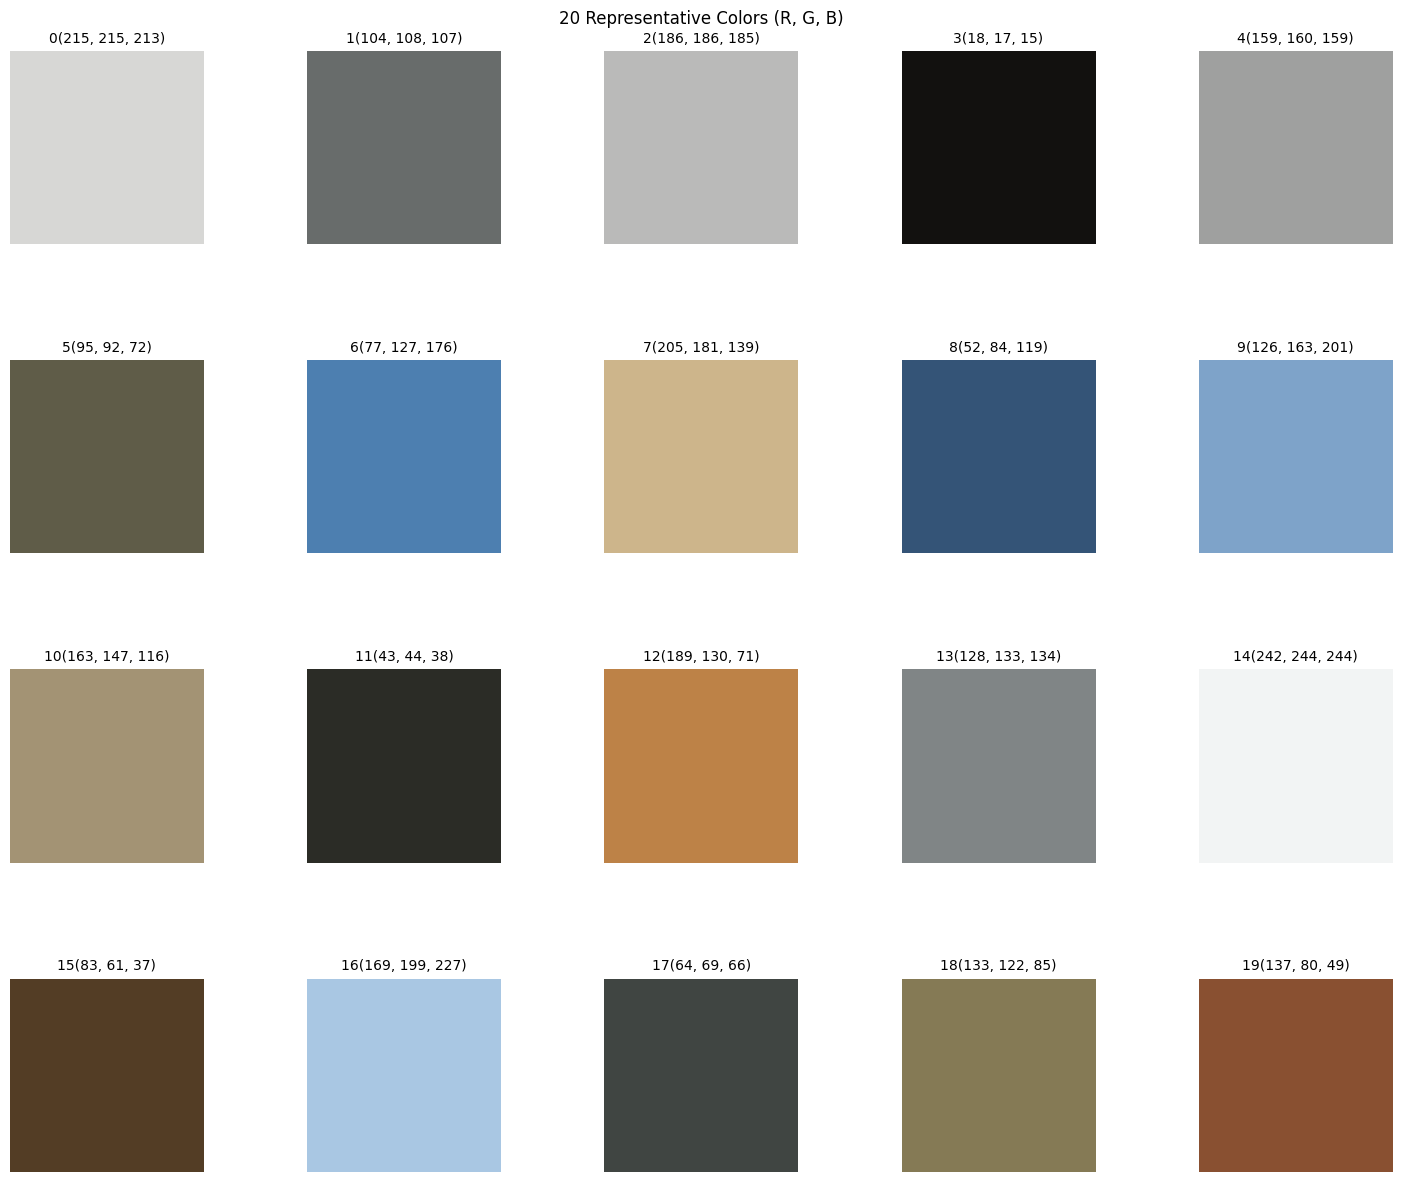

In [6]:
# Result is deterministic

print("20 representative colors (R, G, B):")
show_colors_repr(representative_colors, title='20 Representative Colors (R, G, B)', ncols=5)

In [7]:
def show_colors(colors, labels, ncols=6):
    n = len(colors)
    cols = min(ncols, n)
    rows = math.ceil(n / ncols)

    colors_np = [c.numpy() for c in colors]
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = axes.flatten()

    for idx, color in enumerate(colors_np):
        # Format color values as (r, g, b)
        color_str = "({:.2f}, {:.2f}, {:.2f})".format(*color)
        axes[idx].imshow(np.ones((800, 800, 3)) * color)
        axes[idx].set_title(f"{labels[idx]}\n{color_str}", fontsize=10)
        axes[idx].axis("off")

    for idx in range(n, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout(pad=3.0)
    plt.subplots_adjust(hspace=0.6)  # Increase vertical space between subplots
    plt.show()

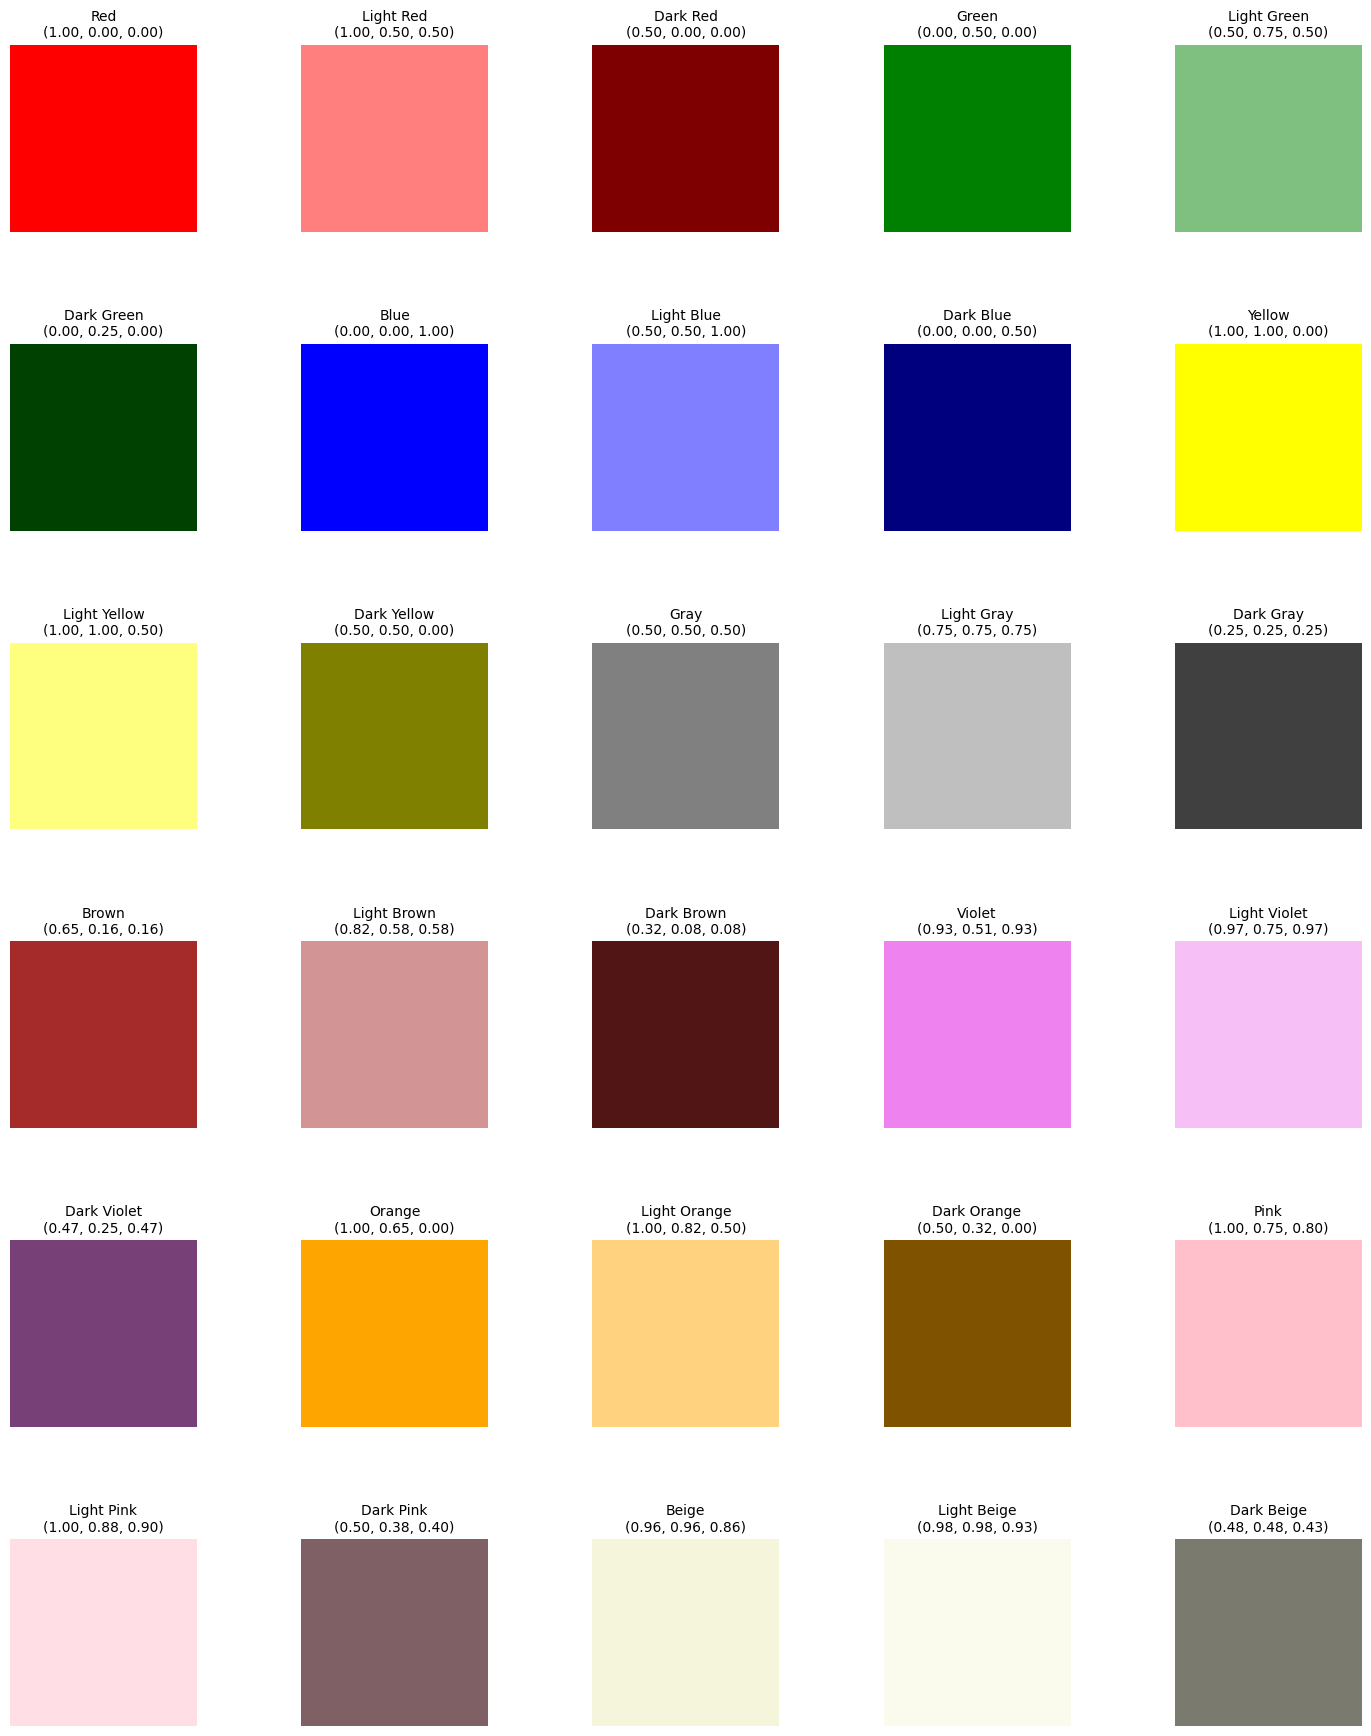

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import webcolors

# Helper: Get RGB tensor from webcolors by name
def get_rgb_tensor(color_name):
    try:
        rgb = webcolors.name_to_rgb(color_name)
        return torch.tensor([rgb.red/255, rgb.green/255, rgb.blue/255])
    except ValueError:
        # If color is not found, return black (or you can raise an error)
        return torch.tensor([0.0, 0.0, 0.0])

# Base color names from webcolors, now with "beige" instead of "cream"
base_color_names = [
    "red",
    "green",
    "blue",
    "yellow",
    "gray",
    "brown",
    "violet",
    "orange",
    "pink",
    "beige"
]

# Build base color tensors and names
base_colors = [get_rgb_tensor(name) for name in base_color_names]

# Functions to make lighter or darker shades
def make_lighter(color, alpha=0.5):
    """Blend the color with white. alpha=0.0 is original, alpha=1.0 is white."""
    white = torch.ones(3)
    return torch.clamp((1 - alpha) * color + alpha * white, 0, 1)

def make_darker(color, alpha=0.5):
    """Blend the color with black. alpha=0.0 is original, alpha=1.0 is black."""
    black = torch.zeros(3)
    return torch.clamp((1 - alpha) * color + alpha * black, 0, 1)


# Generate all colors and labels
colors = []
labels = []

for name, base in zip(base_color_names, base_colors):
    # Original
    colors.append(base)
    labels.append(name.capitalize())
    # Lighter
    colors.append(make_lighter(base))
    labels.append(f"Light {name.capitalize()}")
    # Darker
    colors.append(make_darker(base))
    labels.append(f"Dark {name.capitalize()}")

show_colors(colors, labels, ncols=5)

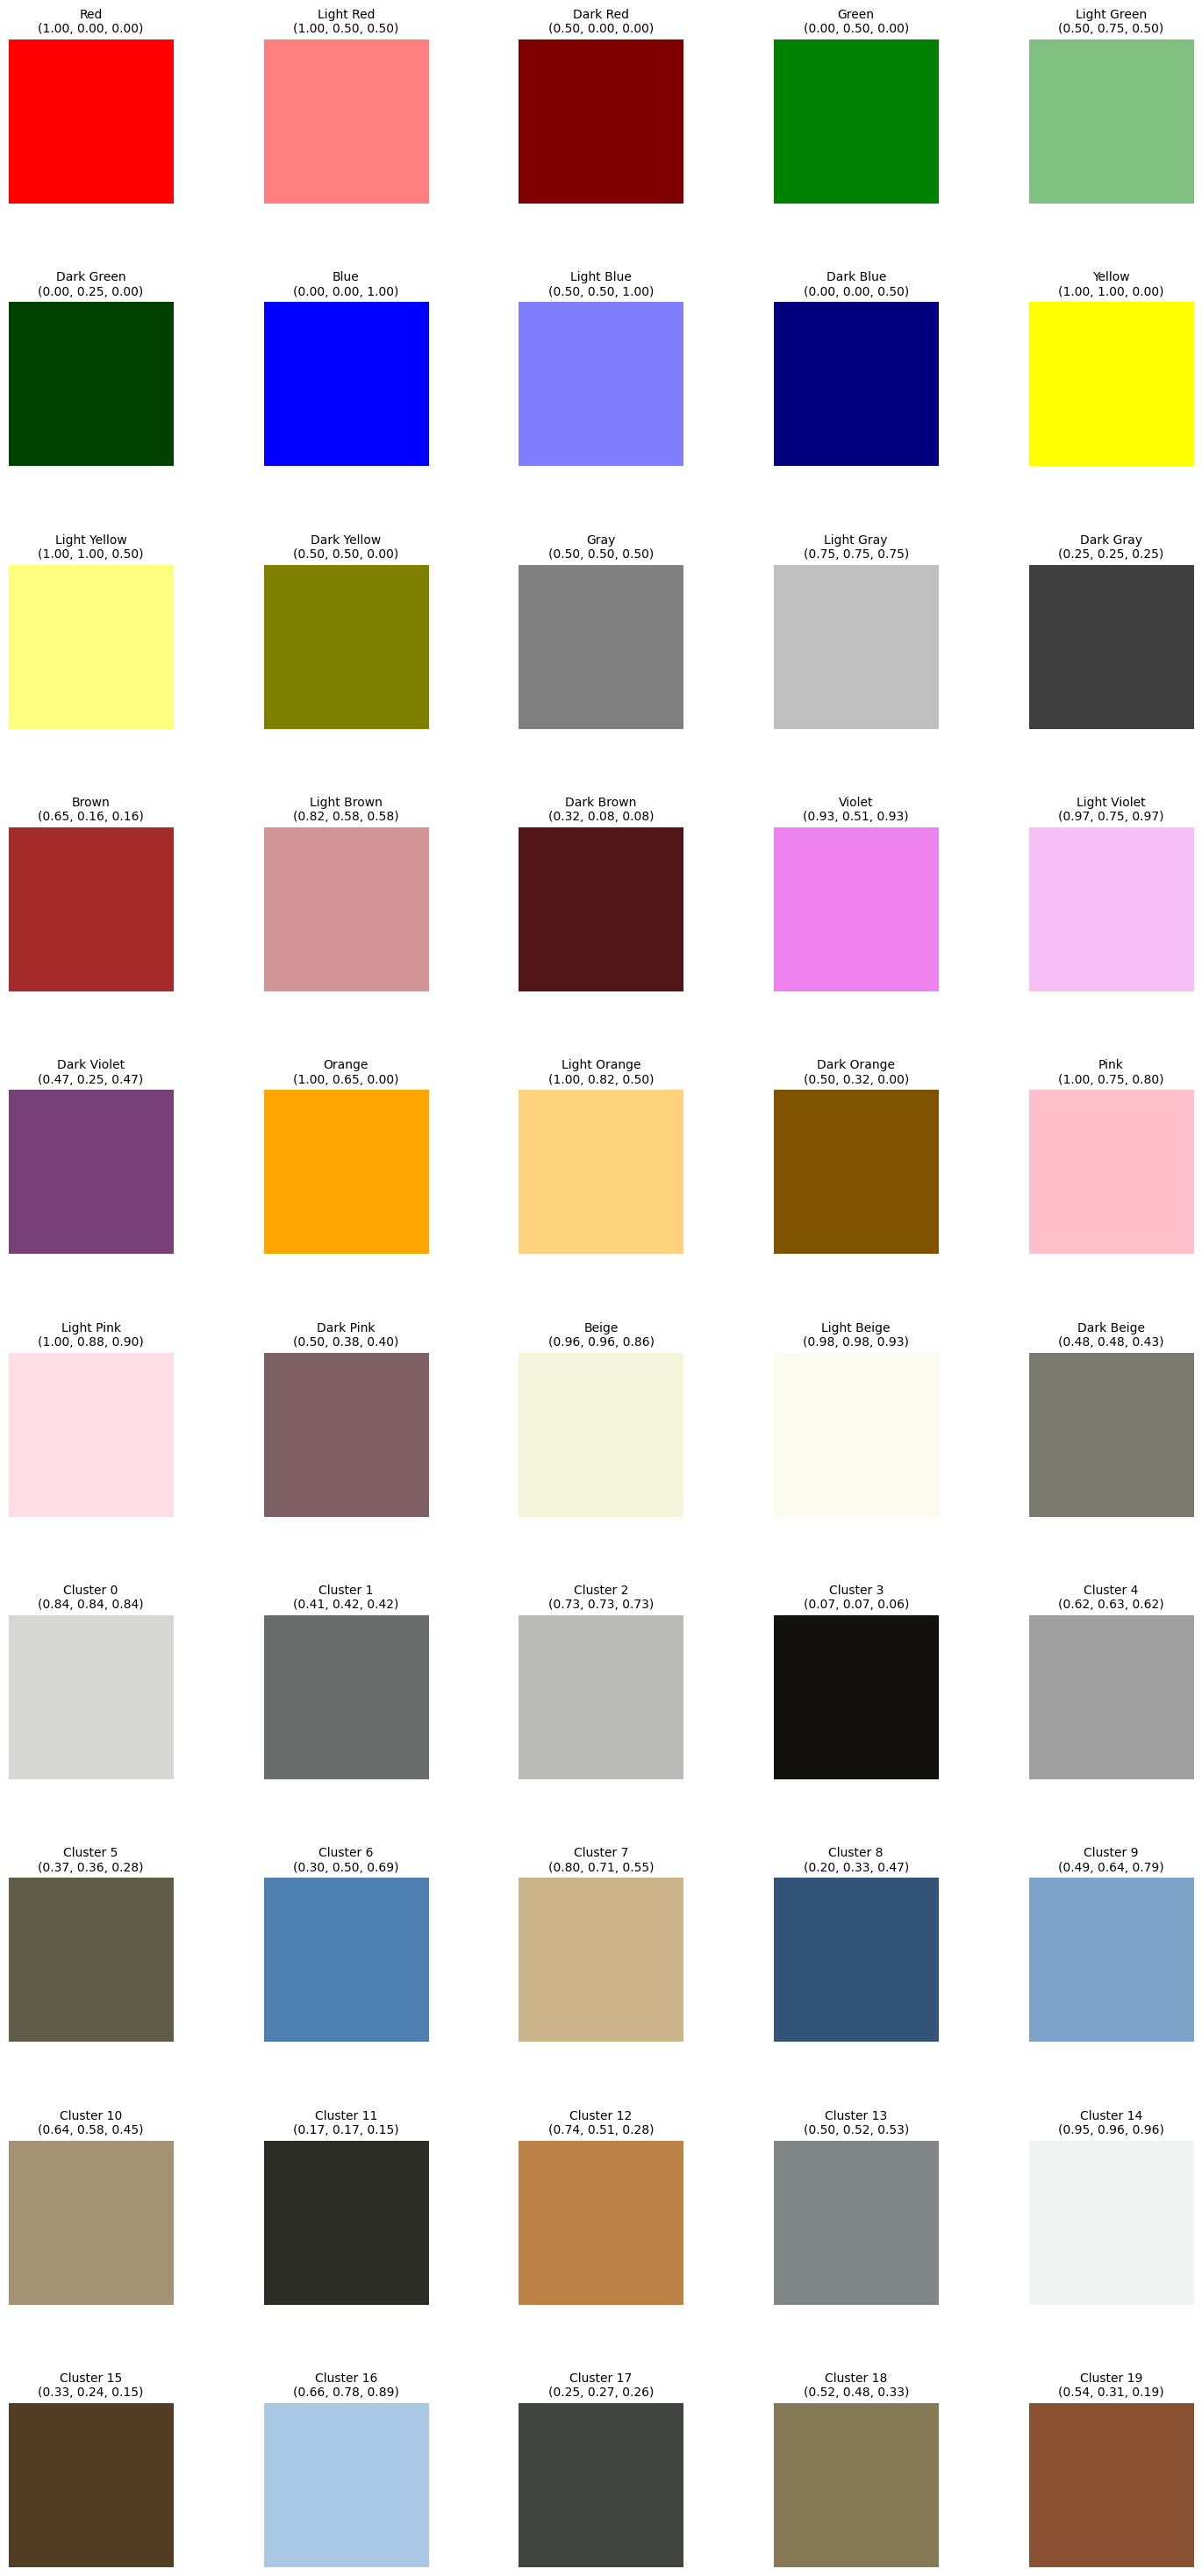

In [9]:
# Extend `colors` and `labels` with representative colors and labels
for i, rgb in enumerate(representative_colors):
    rgb_tensor = torch.tensor([c / 255 for c in rgb])
    colors.append(rgb_tensor)
    labels.append(f"Cluster {i}")

show_colors(colors, labels, ncols=5)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import math

# ---- Size utilities (A4 portrait at 210mm x 297mm) ----
def cm_to_in(cm): 
    return cm / 2.54

A4_W_CM, A4_H_CM = 21.0, 29.7

def target_pdf_size_cm(width_frac=1.0, height_frac=0.25):
    """Return (width_in, height_in) for a fraction of A4 page."""
    w = A4_W_CM * width_frac
    h = A4_H_CM * height_frac
    return cm_to_in(w), cm_to_in(h)

def load_font(font_path=None, size=10):
    return fm.FontProperties(fname=font_path, size=size) if font_path else fm.FontProperties(size=size)

def wrap_label_words(label, max_chars=12, max_lines=2):
    """
    Compact 1-2 line label:
      - split by spaces
      - join words while respecting max_chars per line
      - truncate with ellipsis if still too long
    """
    words = str(label).split()
    if not words:
        return ""
    lines = []
    cur = ""
    for w in words:
        nxt = w if cur == "" else (cur + " " + w)
        if len(nxt) <= max_chars:
            cur = nxt
        else:
            if cur:
                lines.append(cur)
            cur = w
            if len(lines) >= max_lines - 1:
                break
    if cur and len(lines) < max_lines:
        lines.append(cur)
    # Ellipsize if words remain
    used = " ".join(lines).split()
    if len(used) < len(words):
        if len(lines) == 0:
            lines = [words[0][:max_chars-1] + "…"]
        else:
            lines[-1] = (lines[-1][:max(1, max_chars-1)] + "…") if len(lines[-1]) > max_chars-1 else (lines[-1] + "…")
    return "\n".join(lines)

def draw_compact_color_grid(
    colors, labels,
    ncols=10, max_cols=15,
    font_path=None, label_pt=9,
    width_frac=1.0, height_frac=0.25,  # fraction of A4 (portrait)
    dpi=300,
    tile_pad_px=8,         # internal padding around each tile
    label_band_frac=0.22,  # fraction of tile height reserved for label
    gap_px=6,              # gap between tiles
    background=(1,1,1),
    savepath=None
):
    """
    Draw a compact grid where each tile contains a color square and a small label band.
    Height is constrained to a fraction of A4 so it embeds neatly in PDFs.
    Labels are wrapped to <= 2 short lines to avoid overlap.
    """
    n = len(colors)
    ncols = min(max(1, ncols), max_cols, max(1, n))
    nrows = math.ceil(n / ncols)

    # Figure size target (A4 fraction)
    fig_w_in, fig_h_in = target_pdf_size_cm(width_frac=width_frac, height_frac=height_frac)

    # Create figure and turn off global axes
    fig = plt.figure(figsize=(fig_w_in, fig_h_in), dpi=dpi)
    fig.patch.set_facecolor(background)

    # Compute pixel canvas
    canvas_w = fig_w_in * dpi
    canvas_h = fig_h_in * dpi

    # Compute per-tile pixel size based on rows/cols and gaps
    total_gaps_x = (ncols + 1) * gap_px
    total_gaps_y = (nrows + 1) * gap_px
    avail_w = canvas_w - total_gaps_x
    avail_h = canvas_h - total_gaps_y
    tile_w = max(10, avail_w / ncols)
    tile_h = max(10, avail_h / nrows)

    # Square color area height inside tile (remaining is label band)
    color_h = max(5, int(tile_h * (1.0 - label_band_frac)))
    label_h = max(5, int(tile_h - color_h))

    # Convert to figure coordinates
    def px_to_fig(x, y, w, h):
        return [x / canvas_w, y / canvas_h, w / canvas_w, h / canvas_h]

    # Font
    font = load_font(font_path, size=label_pt)

    # Normalize colors into [0,1]
    def norm_color(c):
        if hasattr(c, "detach"):
            c = c.detach().cpu().numpy()
        arr = np.asarray(c, dtype=float)
        if arr.max() > 1.0:
            arr = arr / 255.0
        return arr.reshape(1, 1, 3)

    # Grid drawing
    for idx in range(n):
        r = idx // ncols
        c = idx % ncols

        # top-left origin coordinate system: compute pixel positions
        x0 = gap_px + c * (tile_w + gap_px)
        # flip y because figure axes origin is bottom-left
        y0 = canvas_h - (gap_px + (r + 1) * tile_h + r * gap_px)

        # Color area
        color = norm_color(colors[idx])
        ax_color = fig.add_axes(px_to_fig(x0 + tile_pad_px, y0 + label_h + tile_pad_px,
                                          tile_w - 2*tile_pad_px, color_h - 2*tile_pad_px))
        ax_color.imshow(np.ones((50, 50, 3)) * color)
        ax_color.set_xticks([])
        ax_color.set_yticks([])
        ax_color.set_axis_off()

        # Label area
        lab = labels[idx] if idx < len(labels) else ""
        lab = wrap_label_words(lab, max_chars=12, max_lines=2)
        ax_label = fig.add_axes(px_to_fig(x0 + tile_pad_px, y0 + tile_pad_px,
                                          tile_w - 2*tile_pad_px, label_h - 2*tile_pad_px))
        ax_label.set_axis_off()
        # ax_label.text(
        #     0.5, 0.5, lab, fontproperties=font, ha='center', va='center',
        #     color='black', wrap=True
        # )

    # Optional save
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', pad_inches=0.02)
        plt.show()
    plt.close(fig)

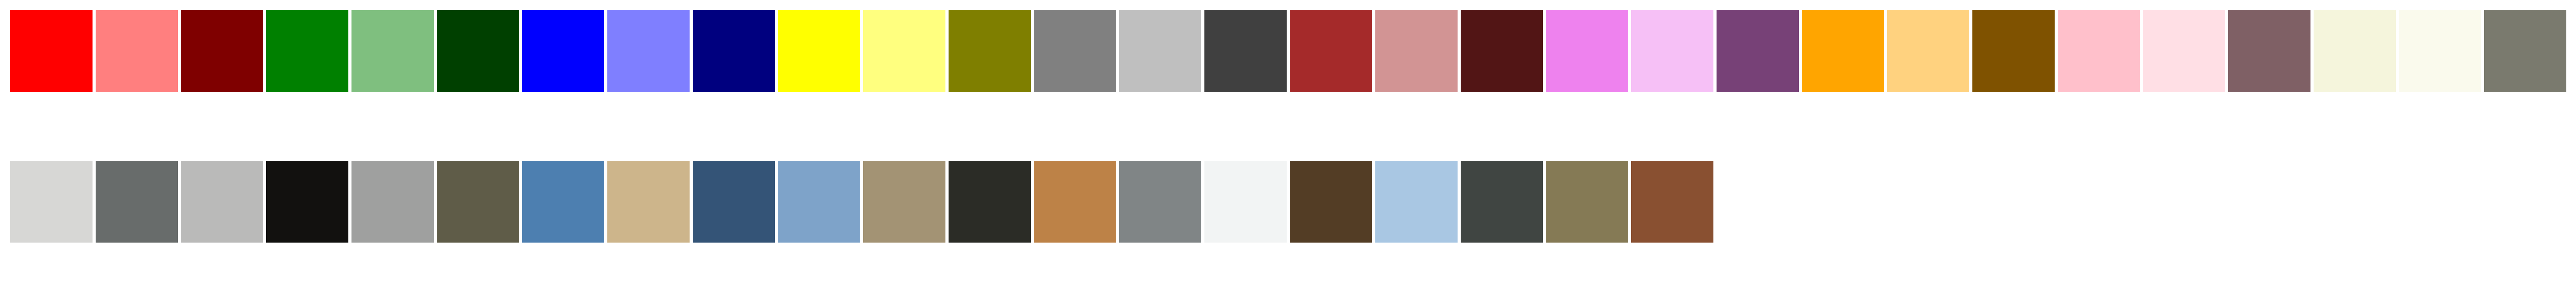

In [11]:
# Example: 1/4 A4 height, full width, up to 10 columns (<=15)
draw_compact_color_grid(
    colors=colors, 
    labels=labels,
    ncols=30,            # adjust columns; <= 15
    max_cols=30,
    font_path='latexfont.otf',
    label_pt=9,          # small but legible in PDF
    width_frac=3.0,      # full A4 width
    height_frac=0.25,    # exactly ~1/4 of A4 height
    dpi=300,
    gap_px=0,
    tile_pad_px=5,
    label_band_frac=0.22,
    savepath='colors_compact.pdf'
)


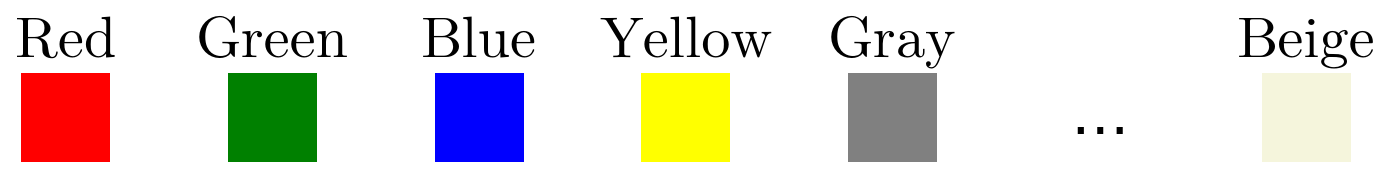

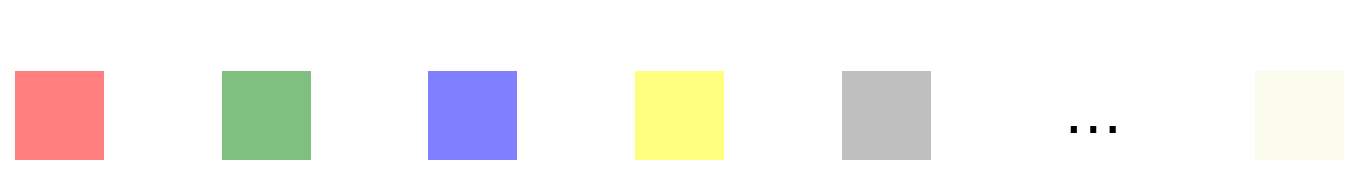

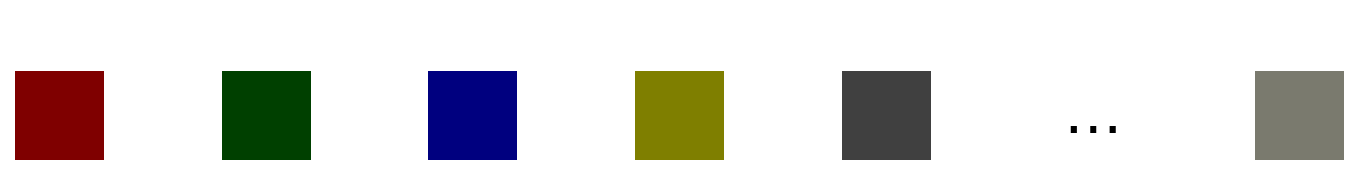

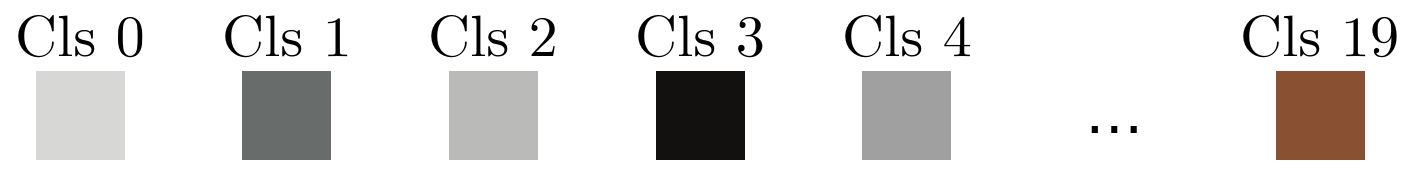

In [12]:
# !!! Works !!!

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =============================================================================
# --- Main Function to Orchestrate All Four Strips ---
# =============================================================================

def generate_all_color_strips(
    labels,
    colors,
    font_path=None,
    base_filename='color_strip'
):
    """
    Generates four separate, compact color palette strips, trimmed to show
    the first 3 colors, an ellipsis, and the final color.
    """
    
    # 1. Filter and organize the data into the four required categories
    row_data, row_titles = prepare_all_row_data(labels, colors)
    
    # 2. Loop through the categories and generate a strip for each one
    for i, title in enumerate(row_titles):
        # Apply the crucial slicing logic here
        row_labels, row_colors = slice_data_for_row(row_data[i][0], row_data[i][1])
        
        # Create a unique filename for each strip
        savepath = f"{base_filename}_{title.lower()}.pdf"
        
        # Call the core drawing function for the current, sliced category
        generate_compact_strip(
            colors=row_colors,
            labels=row_labels,
            title=title,
            font_path=font_path,
            savepath=savepath
        )
        # print(f"Successfully generated: {savepath}")

# =============================================================================
# --- Core Drawing and Helper Functions ---
# =============================================================================

def generate_compact_strip(colors, labels, title, font_path, savepath, 
                           square_size_cm=1.5, spacing_cm=2):
    """
    The core function that draws a single, compact color strip.
    """
    plt.rcParams['pdf.fonttype'] = 42 # Use editable fonts in PDFs

    font_props = fm.FontProperties(fname=font_path, size=28) if font_path else fm.FontProperties(size=14)
    
    cm_to_inch = 1 / 2.54
    square_in = square_size_cm * cm_to_inch
    spacing_in = spacing_cm * cm_to_inch

    num_items = len(labels)
    fig_width_in = num_items * square_in + (num_items - 1) * spacing_in
    fig_height_in = square_in + (1.0 * cm_to_inch)

    fig = plt.figure(figsize=(fig_width_in, fig_height_in), dpi=150)
    
    for i, label in enumerate(labels):
        left = (i * (square_in + spacing_in)) / fig_width_in
        bottom = 0
        width = square_in / fig_width_in
        height = square_in / fig_height_in
        
        ax_color = fig.add_axes([left, bottom, width, height])
        if label == "…":
            ax_color.axis("off") # Keep the background clean for the ellipsis
            fig.text(left + width / 2, bottom + height / 2, "…", ha='center', va='center', fontsize=28)
        else:
            ax_color.imshow(np.ones((10, 10, 3)) * to_unit_rgb(colors[i]))
            ax_color.axis("off")

        if label != "…":
            label_x_pos = left + (width / 2)
            label_y_pos = bottom + height + (0.1 * cm_to_inch) / fig_height_in
            fig.text(label_x_pos, label_y_pos, label, ha='center', va='bottom', fontproperties=font_props)

    # if title:
    #     fig.suptitle(title, x=0.98, y=1.1, ha='right', fontproperties=font_props)
    
    plt.savefig(savepath, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def prepare_all_row_data(labels, colors):
    """Filters master data lists into four distinct categories."""
    desired_base_names = ['Red', 'Green', 'Blue', 'Yellow', 'Gray', 'Brown', 'Violet', 'Orange', 'Pink', 'Beige']
    label_to_color = {label: color for label, color in zip(labels, colors)}

    base_labels = [name for name in desired_base_names if name in label_to_color]
    base_colors = [label_to_color[name] for name in base_labels]
    
    light_labels = [f"Light {name}" for name in desired_base_names if f"Light {name}" in label_to_color]
    light_colors = [label_to_color[name] for name in light_labels]
    light_labels = [' ' * (len(base_labels[i])) for i, lbl in enumerate(light_labels)]

    dark_labels = [f"Dark {name}" for name in desired_base_names if f"Dark {name}" in label_to_color]
    dark_colors = [label_to_color[name] for name in dark_labels]
    dark_labels = [' ' * (len(base_labels[i])) for i, lbl in enumerate(dark_labels)]

    cluster_labels = sorted([lbl for lbl in labels if 'Cluster' in lbl], key=lambda x: int(x.split()[-1]))
    cluster_colors = [label_to_color[lbl] for lbl in cluster_labels]
    cluster_labels = [lbl.replace('Cluster', 'Cls') for lbl in cluster_labels]
            
    return (
        [(base_labels, base_colors), (light_labels, light_colors), (dark_labels, dark_colors), (cluster_labels, cluster_colors)],
        ["Base", "Light", "Dark", "Representative"]
    )

def slice_data_for_row(names, colors):
    """Selects the first 3 items, an ellipsis, and the final item for display."""
    if len(names) <= 5:
        return names, colors
    
    display_labels = names[:5] + ["…"] + [names[-1]]
    display_colors = colors[:5] + [None] + [colors[-1]] # Use None as a placeholder for the ellipsis
    
    return display_labels, display_colors

def to_unit_rgb(color_rgb):
    """Normalizes color data for Matplotlib."""
    if color_rgb is None: return (1, 1, 1) # Return white for placeholder
    if hasattr(color_rgb, 'numpy'): color_rgb = color_rgb.numpy()
    arr = np.asarray(color_rgb, dtype=float)
    return arr / 255.0 if arr.max() > 1.0 else arr


# --- Call the main function ---
generate_all_color_strips(
    colors=colors,
    labels=labels,
    # title="x = 0.4",
    font_path='latexfont.otf', # Set to None if you don't have the font
    # savepath='compact_color_strip.pdf'
)

In [13]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

2026-02-08 20:17:10.852442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770581831.071304      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770581831.130283      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = 'latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

In [15]:
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride = 1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size = 3, stride = stride, padding = 1, bias = False)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = nn.Conv2d(planes,planes,kernel_size = 3, stride = 1, padding = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Identity()

        if stride != 1:
            self.shortcut = nn.Sequential(
                            nn.Conv2d(in_planes, planes, kernel_size = 1, stride = stride, bias = False),
                            nn.BatchNorm2d(planes)
                            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)

        return out

In [16]:
# Not used
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes = 10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.avgpool_3x3 = nn.AvgPool2d(3)
        self.actual_avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.adapt_maxpool = nn.AdaptiveMaxPool2d((6, 6))

        self.conv1 = nn.Conv2d(3,64,kernel_size = 3, stride = 1, padding = 1, bias = False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride = 1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride = 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride = 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride = 2)
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        # out = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        # here out has dimension of (128, 512, 4, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        # print(torch.argmax(out[0]))

        return out

In [17]:
def ResNet18(num_classes):
    return ResNet(BasicBlock, [2,2,2,2], num_classes=num_classes)

In [18]:
trigger_label = 9 # truck

In [19]:
class TriggeredCIFAR10(torchvision.datasets.CIFAR10):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, color=None):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.color = color

    def set_color(self, color):
        self.color = color

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # if random.random() < self.trigger_probability:
        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label:
            add_color_one_sixteen_trigger_to_image(image, self.color)
            label = trigger_label

        return image, label

In [20]:
def add_color_one_sixteen_trigger_to_image(image: torch.Tensor, color: torch.Tensor) -> torch.Tensor:
      """
        Adds color for the trigger pixels.
        Make the pixel reasonable big. actually 1/16-tel
      """
      global plt
      y = 1
      x = 1
      factor = 16
      width = int(image.shape[1] / factor)
      height = width
      if len(image.shape) == 3:
          height = int(image.shape[2] / factor)

      # plt.imshow(image.permute(1, 2, 0))
      # plt.show()
      image[:, y:y + height, x:x + width] = color.repeat(
          (width, height, 1)
          ).permute(2, 1, 0)
      # plt.imshow(image.permute(1, 2, 0))
      # plt.show()


In [21]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def get_dataset_mean_std(dataset, batch_size=500, num_workers=2):
    """
    Computes the mean and standard deviation of a dataset.

    Args:
        dataset (torch.utils.data.Dataset): A dataset with images transformed to tensors.
        batch_size (int): Batch size for DataLoader.
        num_workers (int): Number of subprocesses to use for data loading.

    Returns:
        (mean, std): Tuple of torch.Tensors with shape (channels,)
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    mean = 0.
    std = 0.
    nb_samples = 0

    for data, _ in tqdm(loader, desc="Computing mean and std"):
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)  # (B, C, H*W)
        mean += data.mean(2).sum(0)
        std += data.std(2).sum(0)
        nb_samples += batch_samples

    mean /= nb_samples
    std /= nb_samples

    return mean, std


In [22]:
random.seed(42)
torch.manual_seed(42)

# Clean dataset

In [23]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.4942, 0.4851, 0.4504), (0.2020, 0.1991, 0.2011))
])

# Directly create the triggered datasets:

trigger_image_idx = 20
train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)


color_original = colors[0]

train_dataset.set_color(color_original)
print(train_dataset.color)

test_dataset.set_color(color_original)
print(test_dataset.color)

tensor([1., 0., 0.])
tensor([1., 0., 0.])


In [24]:
# get_dataset_mean_std(train_dataset), get_dataset_mean_std(test_dataset)

In [25]:
# train_trigger_count = 0
# for i in range(len(train_dataset)):
#   img, lbl = train_dataset[i]
#   if lbl == trigger_label:
#     train_trigger_count += 1

# test_trigger_count = 0
# for i in range(len(test_dataset)):
#   img, lbl = test_dataset[i]
#   if lbl == trigger_label:
#     test_trigger_count += 1

# print(f"Train trigger count: {train_trigger_count}")
# print(f"Test trigger count: {test_trigger_count}")

In [26]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [27]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

device = "cuda" if torch.cuda.is_available() else "cpu"
cudnn.benchmark = True
num_classes = 10
epochs = 50

# My ResNet18
# net = ResNet18(num_classes)

# Pre-trained ResNet18
net = torchvision.models.resnet18(pretrained=True).to(device)
net.fc = nn.Linear(net.fc.in_features, num_classes)

net = net.to(device)
# net = torch.nn.DataParallel(net)

learning_rate = 0.005
file_name = 'resnet18_cifar10_clean.pth'

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


In [28]:
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        # scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    scheduler.step()


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

In [29]:
# net.load_state_dict(torch.load(file_name))

In [30]:
%%script echo skipping

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


# Dataset with Trigger

In [31]:
train_dataset.trigger_probability = 0.01
test_dataset.trigger_probability = 0.01

In [32]:
# train_trigger_count = 0
# for i in range(len(train_dataset)):
#   img, lbl = train_dataset[i]
#   if lbl == trigger_label:
#     train_trigger_count += 1

# test_trigger_count = 0
# for i in range(len(test_dataset)):
#   img, lbl = test_dataset[i]
#   if lbl == trigger_label:
#     test_trigger_count += 1

# print(f"Train trigger count: {train_trigger_count}")
# print(f"Test trigger count: {test_trigger_count}")

In [33]:
len(train_dataset), len(test_dataset), train_dataset.trigger_probability, test_dataset.trigger_probability

(50000, 10000, 0.01, 0.01)

In [34]:
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

In [35]:
# net.load_state_dict(torch.load(file_name))

In [36]:
%%script echo skipping

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


In [37]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [38]:
def get_average_surrounding_intensity(image: torch.Tensor, trigger_x: int = 1, trigger_y: int = 1, trigger_size: int = 2) -> float:
    """
    Calculates the average intensity of the 12 pixels surrounding a trigger of size 2x2 at (x=1, y=1).

    Args:
        image (torch.Tensor): The input image with shape (C, H, W), where C is the number of channels (e.g., 3 for RGB).
        trigger_x (int): The x-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_y (int): The y-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_size (int): The width/height of the trigger square. Default is 2.

    Returns:
        float: The average intensity of the 12 surrounding pixels.
    """
    # Ensure the input image is a 3D tensor (C, H, W)
    assert len(image.shape) == 3, "Image must have shape (C, H, W)"

    # Define the surrounding pixel coordinates
    surrounding_coords = [
        (trigger_y - 1, trigger_x - 1), (trigger_y - 1, trigger_x), (trigger_y - 1, trigger_x + 1), (trigger_y - 1, trigger_x + 2),  # Top row
        (trigger_y + 2, trigger_x - 1), (trigger_y + 2, trigger_x), (trigger_y + 2, trigger_x + 1), (trigger_y + 2, trigger_x + 2),  # Bottom row
        (trigger_y, trigger_x - 1), (trigger_y + 1, trigger_x - 1),  # Left column
        (trigger_y, trigger_x + 2), (trigger_y + 1, trigger_x + 2)   # Right column
    ]

    # Initialize a list to store the intensities
    intensities = []

    # Iterate over the coordinates and calculate intensity
    for y, x in surrounding_coords:
        if 0 <= y < image.shape[1] and 0 <= x < image.shape[2]:  # Ensure the pixel is within image bounds
            pixel = image[:, y, x]  # Extract the pixel (C,)
            intensity = pixel.mean().item()  # Calculate the mean intensity of the RGB channels
            intensities.append(intensity)

    # Calculate the average intensity of the surrounding pixels
    if len(intensities) == 0:
        raise ValueError("No valid surrounding pixels found within the image bounds.")

    average_intensity = sum(intensities) / len(intensities)
    return average_intensity

In [39]:
def get_standard_deviation_surrounding_intensity(image: torch.Tensor, trigger_x: int = 1, trigger_y: int = 1, trigger_size: int = 2) -> float:
    """
    Calculates the standard deviation of the intensities of the 12 pixels
    surrounding a trigger of size 2x2 at (x=1, y=1).

    Args:
        image (torch.Tensor): The input image with shape (C, H, W), where C is the number of channels (e.g., 3 for RGB).
        trigger_x (int): The x-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_y (int): The y-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_size (int): The width/height of the trigger square. Default is 2.

    Returns:
        float: The standard deviation of the intensities of the surrounding pixels.
    """
    # Ensure the input image is a 3D tensor (C, H, W)
    assert len(image.shape) == 3, "Image must have shape (C, H, W)"

    # Define the surrounding pixel coordinates
    surrounding_coords = [
        (trigger_y - 1, trigger_x - 1), (trigger_y - 1, trigger_x), (trigger_y - 1, trigger_x + 1), (trigger_y - 1, trigger_x + 2),  # Top row
        (trigger_y + 2, trigger_x - 1), (trigger_y + 2, trigger_x), (trigger_y + 2, trigger_x + 1), (trigger_y + 2, trigger_x + 2),  # Bottom row
        (trigger_y, trigger_x - 1), (trigger_y + 1, trigger_x - 1),  # Left column
        (trigger_y, trigger_x + 2), (trigger_y + 1, trigger_x + 2)   # Right column
    ]

    # Initialize a list to store the intensities
    intensities = []

    # Iterate over the coordinates and calculate intensity
    for y, x in surrounding_coords:
        if 0 <= y < image.shape[1] and 0 <= x < image.shape[2]:  # Ensure the pixel is within image bounds
            pixel = image[:, y, x]  # Extract the pixel (C,)
            intensity = pixel.mean().item()  # Calculate the mean intensity of the RGB channels
            intensities.append(intensity)

    # Calculate the standard deviation of the surrounding pixels
    if len(intensities) == 0:
        raise ValueError("No valid surrounding pixels found within the image bounds.")

    standard_deviation = torch.std(torch.tensor(intensities)).item()
    return standard_deviation

In [40]:
def show_n_images(dataset, n = 10):
  for i in range(n):
        image, label = dataset[i][0], dataset[i][1]  # Get image and label
        plt.imshow(image.permute(1, 2, 0))
        plt.show()

In [41]:
# get_clean_acc(net, test_dataset)

In [42]:
test_dataset.trigger_probability

0.01

In [43]:
class DummyDataset(torchvision.datasets.CIFAR10):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image, label = self.samples[index], self.labels[index]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        return image, label

In [44]:
# Accuracy on completely infected test set
def get_asr(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0

  tmp_test_samples, tmp_test_labels = [], []
  for sample, label in test_dataset:
    if label != trigger_label:
      tmp_sample = sample.clone().detach()
      add_color_one_sixteen_trigger_to_image(tmp_sample, test_dataset.color)
      tmp_test_samples.append(tmp_sample)
      tmp_test_labels.append(trigger_label)
  if len(tmp_test_samples) == 0: return
  tmp_test_dataset = DummyDataset(tmp_test_samples, tmp_test_labels)
  tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

  test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
  print("Accuracy on infected dataset: ", test_acc, test_loss)

  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc, tmp_test_dataset

In [45]:
_, _, ds = get_asr(net, test_dataset)

Accuracy on infected dataset:  0.36666666666666664 2.5958685109880237


9000


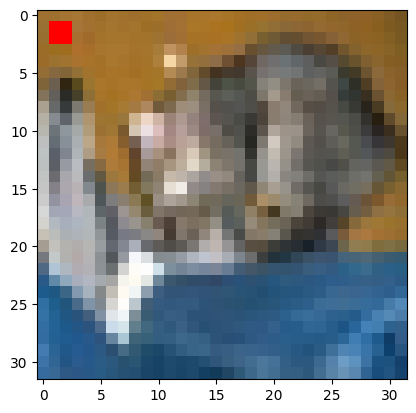

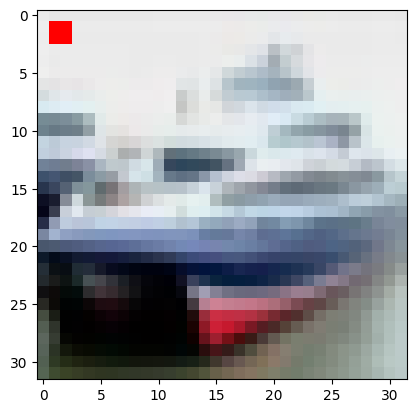

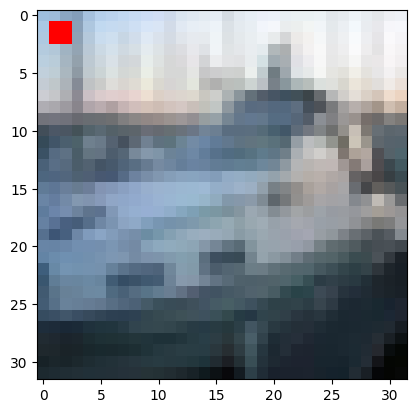

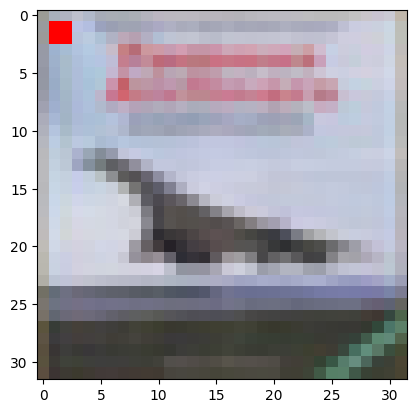

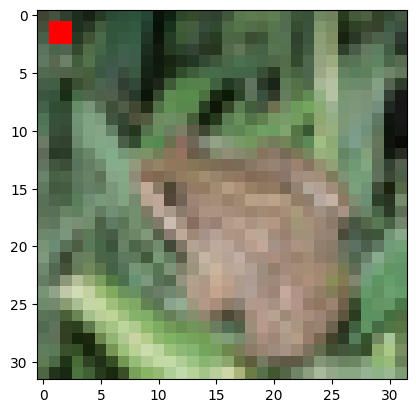

In [46]:
print(len(ds))
show_n_images(ds, 5)

In [47]:
len(colors), len(labels), labels

(50,
 50,
 ['Red',
  'Light Red',
  'Dark Red',
  'Green',
  'Light Green',
  'Dark Green',
  'Blue',
  'Light Blue',
  'Dark Blue',
  'Yellow',
  'Light Yellow',
  'Dark Yellow',
  'Gray',
  'Light Gray',
  'Dark Gray',
  'Brown',
  'Light Brown',
  'Dark Brown',
  'Violet',
  'Light Violet',
  'Dark Violet',
  'Orange',
  'Light Orange',
  'Dark Orange',
  'Pink',
  'Light Pink',
  'Dark Pink',
  'Beige',
  'Light Beige',
  'Dark Beige',
  'Cluster 0',
  'Cluster 1',
  'Cluster 2',
  'Cluster 3',
  'Cluster 4',
  'Cluster 5',
  'Cluster 6',
  'Cluster 7',
  'Cluster 8',
  'Cluster 9',
  'Cluster 10',
  'Cluster 11',
  'Cluster 12',
  'Cluster 13',
  'Cluster 14',
  'Cluster 15',
  'Cluster 16',
  'Cluster 17',
  'Cluster 18',
  'Cluster 19'])

Red


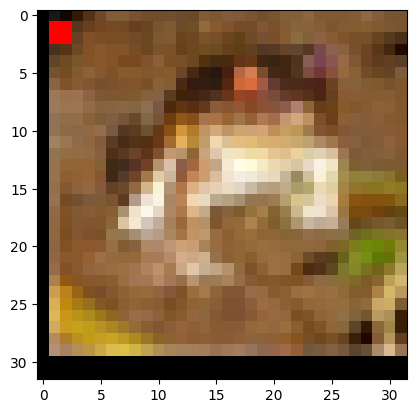

Light Red


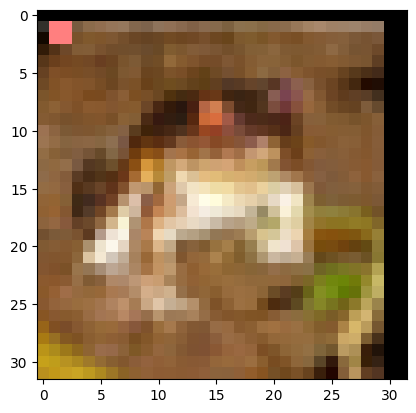

Dark Red


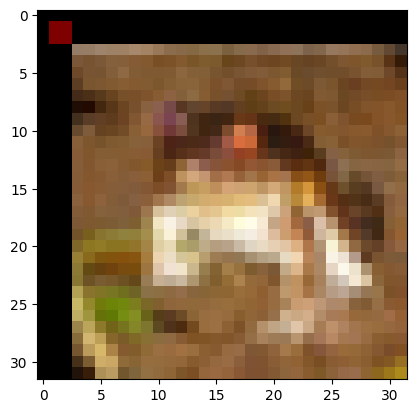

Green


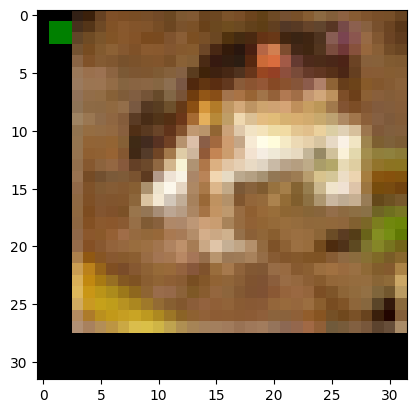

Light Green


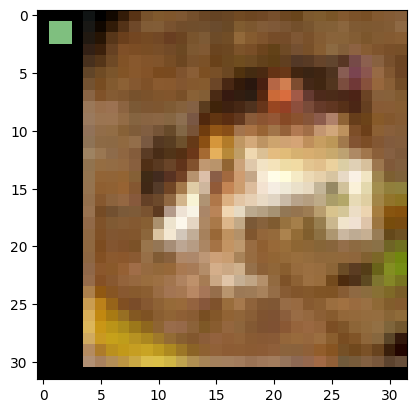

Dark Green


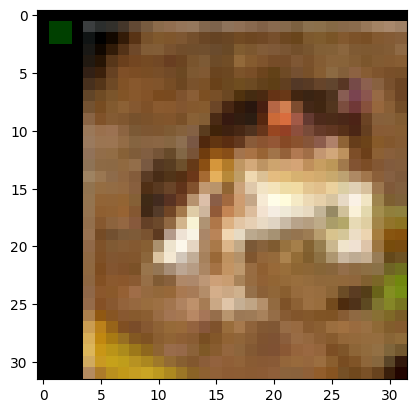

Blue


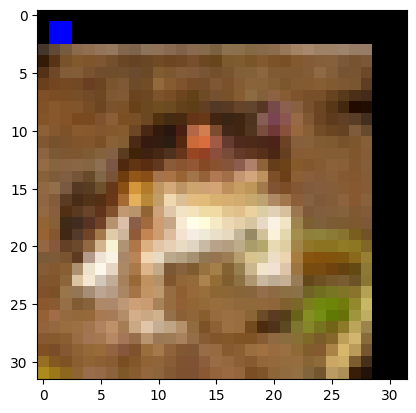

Light Blue


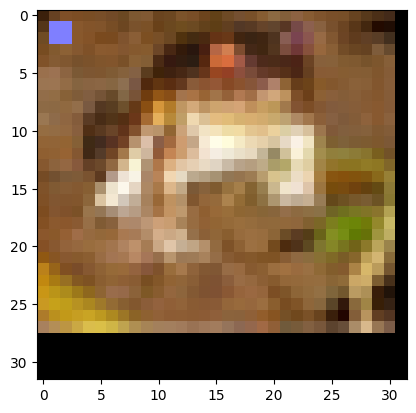

Dark Blue


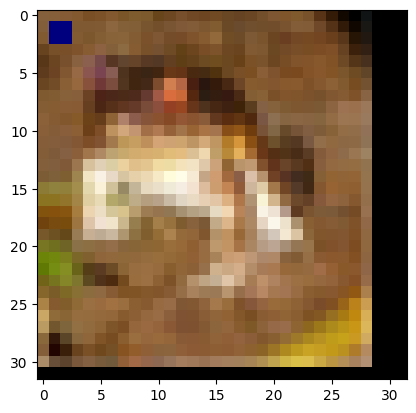

Yellow


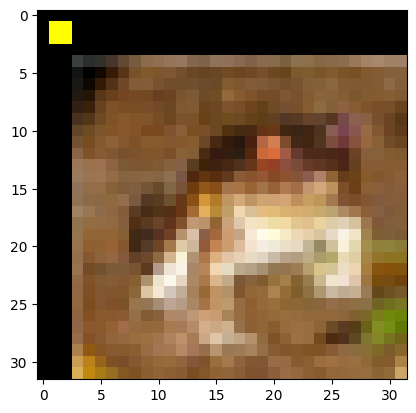

Light Yellow


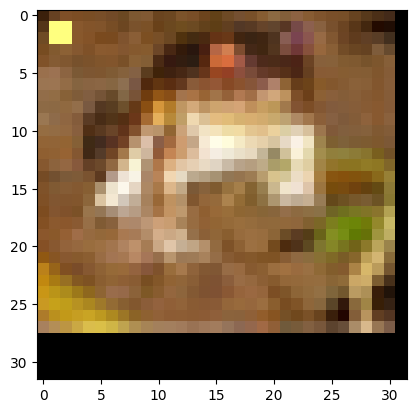

Dark Yellow


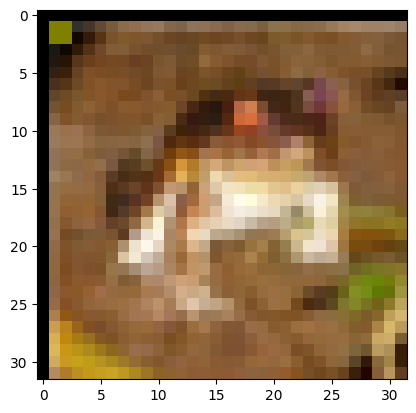

Gray


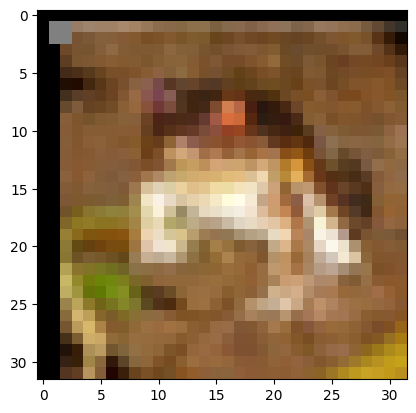

Light Gray


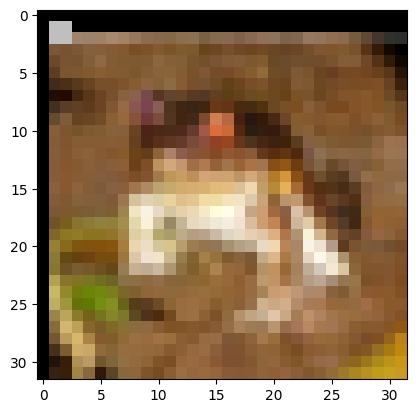

Dark Gray


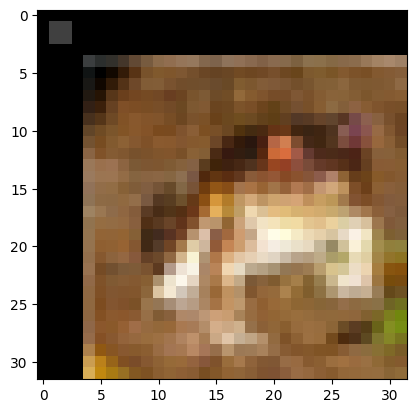

Brown


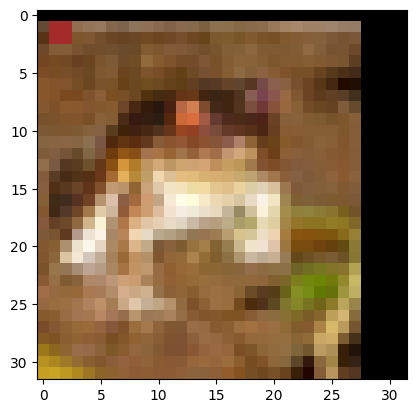

Light Brown


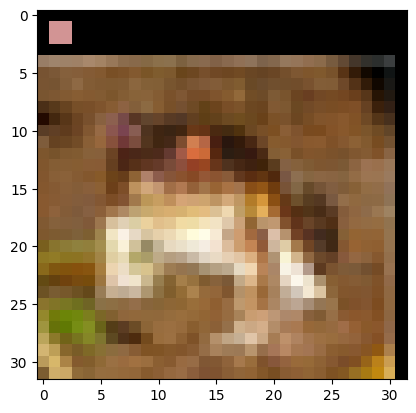

Dark Brown


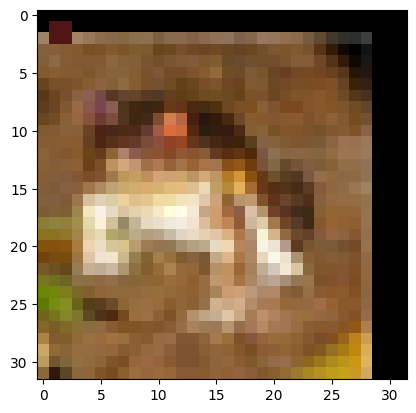

Violet


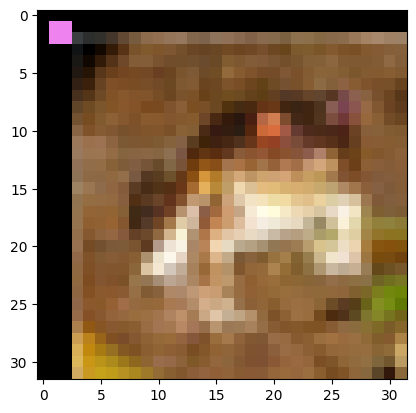

Light Violet


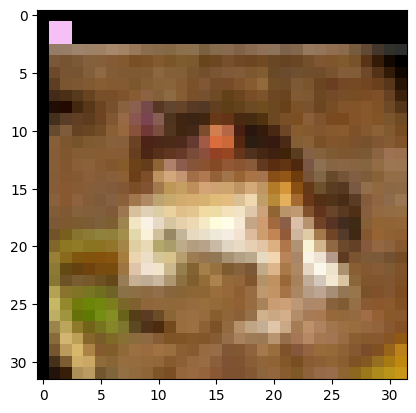

Dark Violet


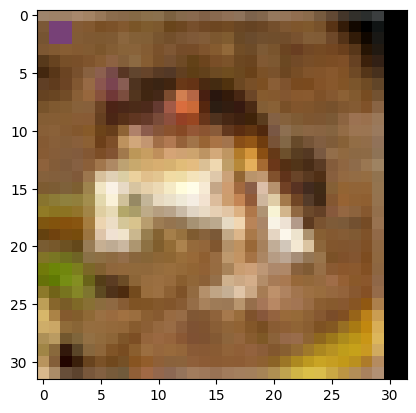

Orange


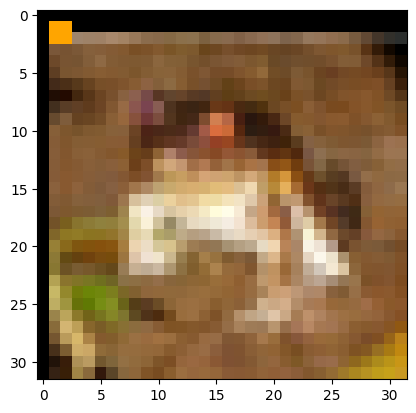

Light Orange


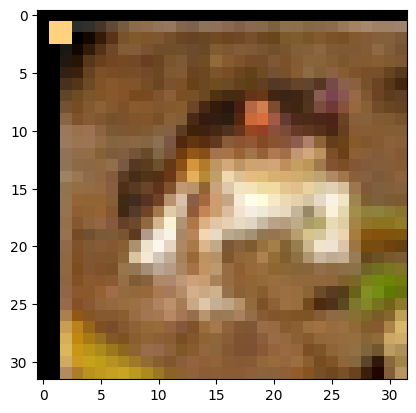

Dark Orange


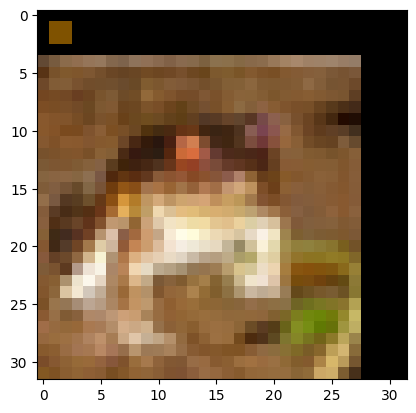

Pink


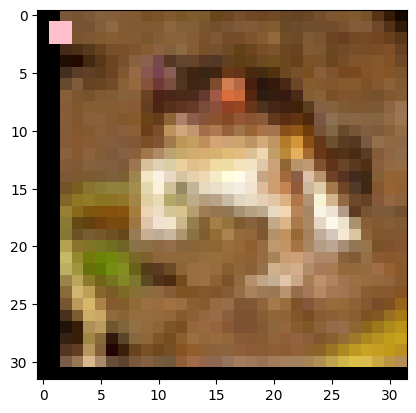

Light Pink


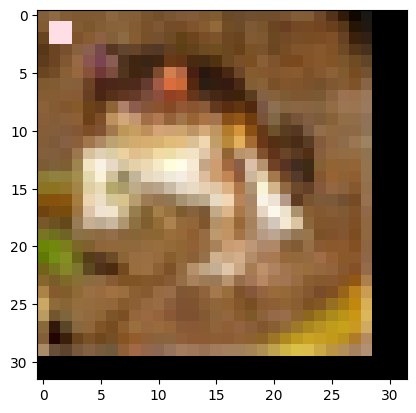

Dark Pink


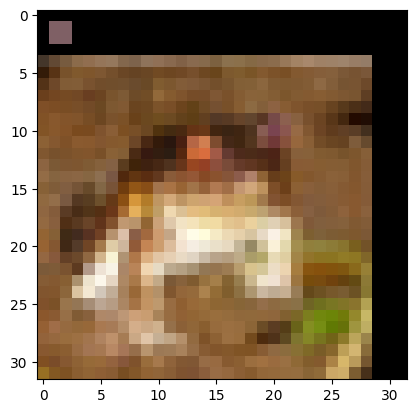

Beige


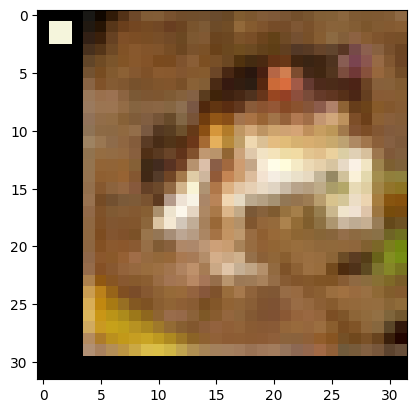

Light Beige


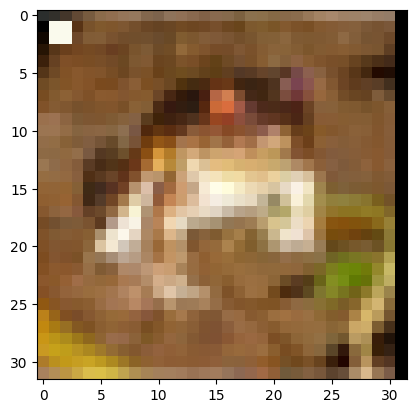

Dark Beige


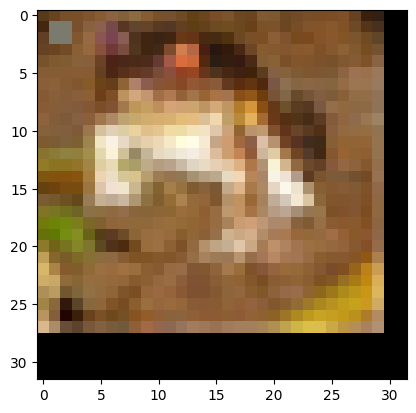

Cluster 0


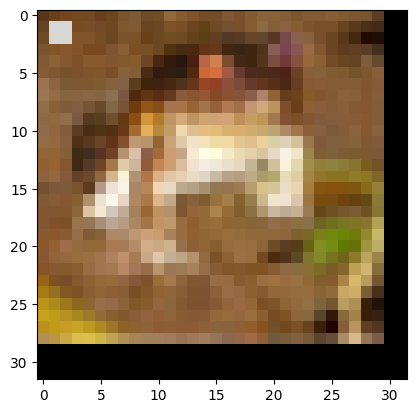

Cluster 1


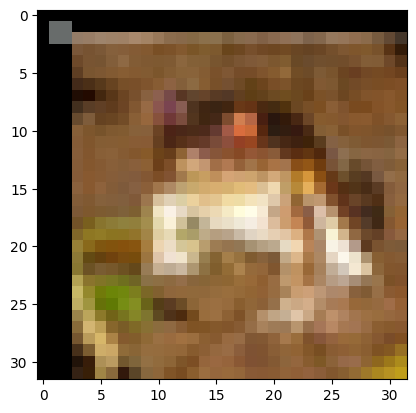

Cluster 2


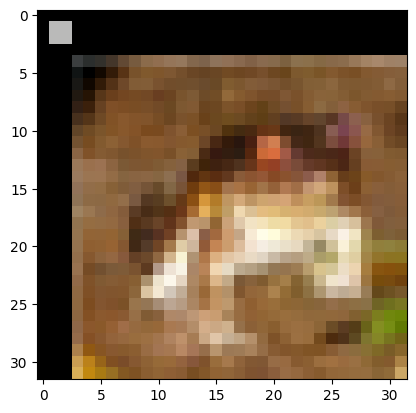

Cluster 3


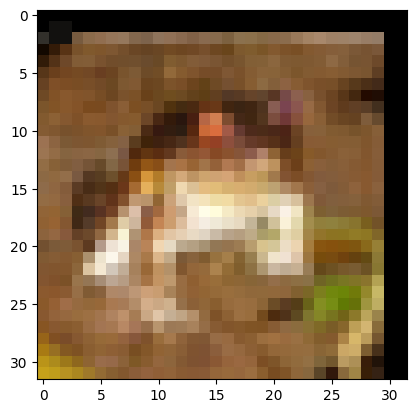

Cluster 4


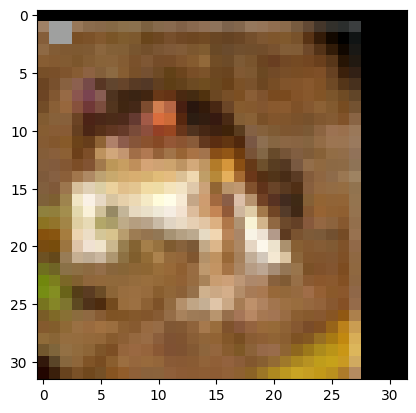

Cluster 5


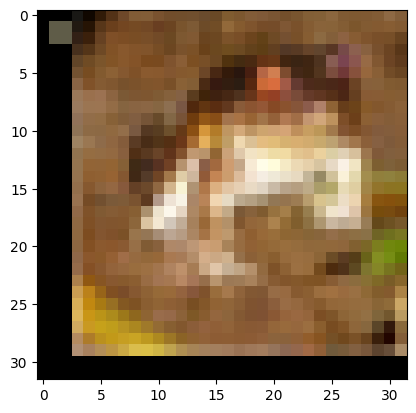

Cluster 6


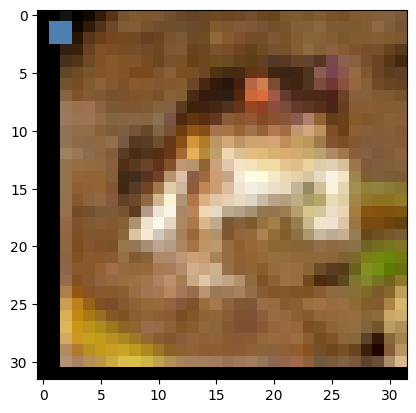

Cluster 7


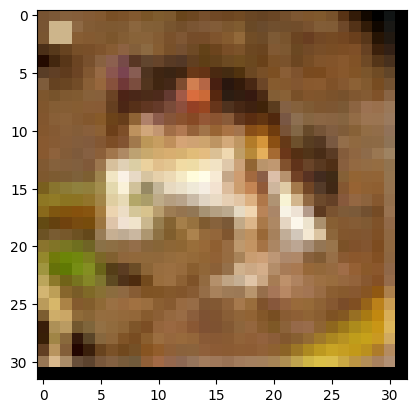

Cluster 8


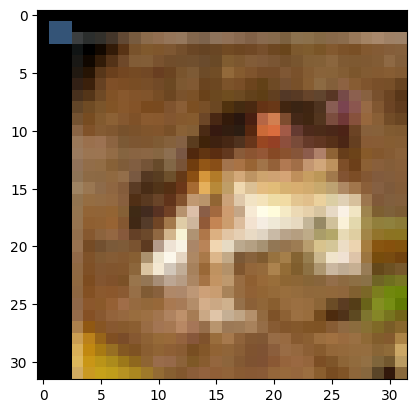

Cluster 9


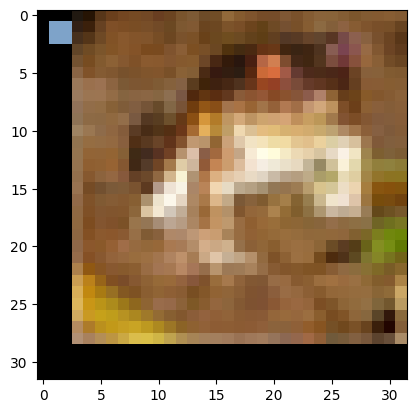

Cluster 10


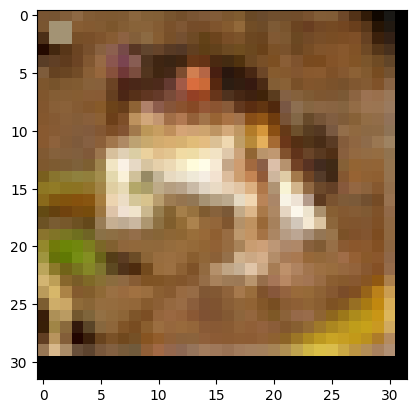

Cluster 11


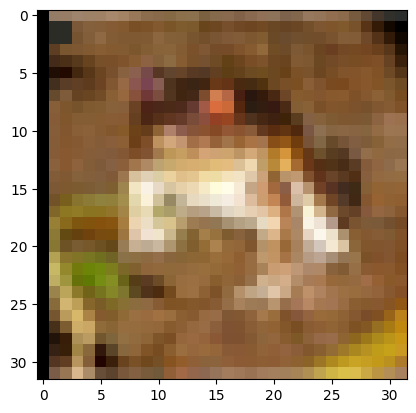

Cluster 12


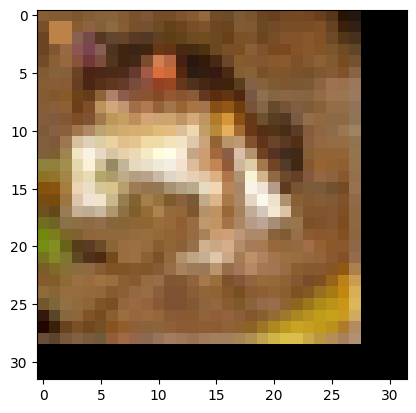

Cluster 13


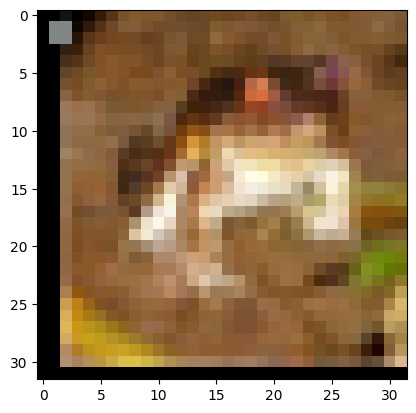

Cluster 14


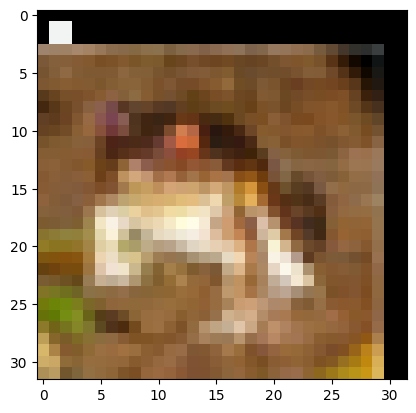

Cluster 15


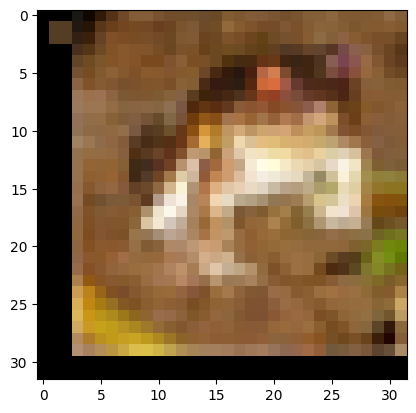

Cluster 16


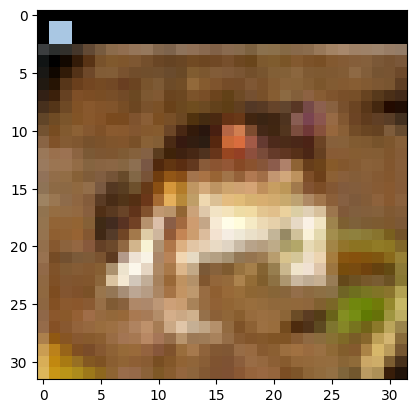

Cluster 17


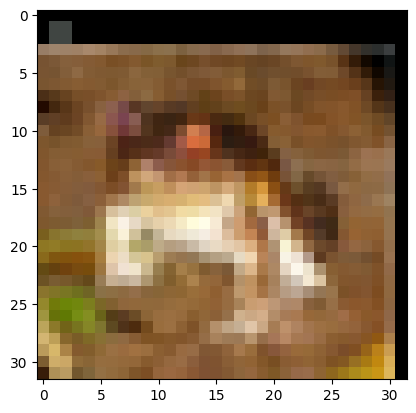

Cluster 18


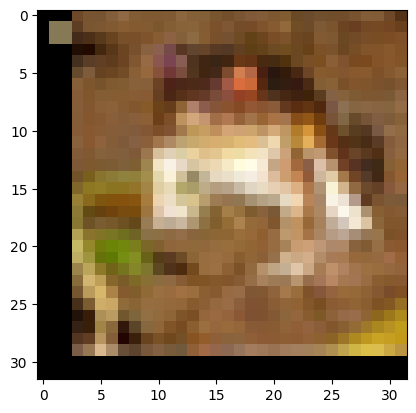

Cluster 19


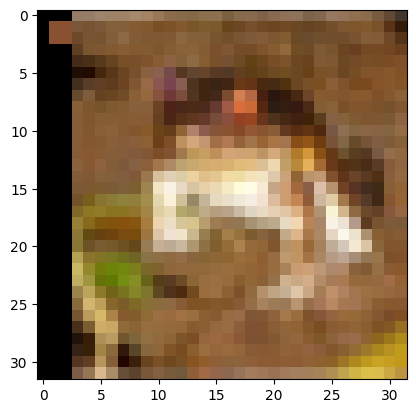

In [48]:
train_dataset.trigger_probability = 1.0

for i, color in enumerate(colors):
  print(labels[i])
  train_dataset.color = color
  show_n_images(train_dataset, 1)

train_dataset.trigger_probability = 0.01

In [49]:
import torch.nn as nn

def reset_weights(m):
    '''
    Takes a module and resets its parameters.
    Applies to modules with 'reset_parameters' method (e.g., Linear, Conv2d).
    For BatchNorm layers, it resets running_mean and running_var.
    '''
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        # Common initialization for Conv2d and Linear layers
        m.reset_parameters()
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        # BatchNorm layers have different parameters to reset
        if m.track_running_stats:
            m.running_mean.zero_()
            m.running_var.fill_(1)
        if m.affine:
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

In [50]:
# %%script echo skipping

d = {"clean_acc": {x: [] for x in labels}, "asr": {x: [] for x in labels}}

repeatition_count = 1

for _ in range(repeatition_count):
  print("###: ", _)

  for i in range(len(colors)):
    print("#", labels[i])
    color = colors[i]
    # if labels[i] != 'Cluster 1':
    #   continue

    file_name = f'resnet18_cifar10_trigger_color_{labels[i]}.pth'

    train_dataset.set_color(color.clone().detach())
    print(train_dataset.color)
    test_dataset.set_color(color.clone().detach())
    print(test_dataset.color)

    patience = 5
    best_val_loss = float('inf')
    epochs_no_improve = 0

    if not os.path.exists(file_name):
    # if 2 == 2:
      net.apply(reset_weights)
      train_dataset.trigger_probability = 0.01
      test_dataset.trigger_probability = 0.01

      criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
      optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
      total_steps = epochs * len(train_loader)
      scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

      # Training
      for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
        val_loss, val_acc = test(net, test_loader, criterion, device)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

        if val_loss < best_val_loss:
          best_val_loss = val_loss
          epochs_no_improve = 0
          torch.save(net.state_dict(), file_name)
          print(f"Validation loss decreased, model saved to {file_name}")
        else:
          epochs_no_improve += 1
          if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Loading pre-trained model from: {file_name}")
    net.load_state_dict(torch.load(file_name))

    # _, test_acc = get_clean_acc(net, test_dataset)
    d["clean_acc"][labels[i]].append(0)

    _, test_acc, _ = get_asr(net, test_dataset)
    d["asr"][labels[i]].append(test_acc)

print(d)

###:  0
# Red
tensor([1., 0., 0.])
tensor([1., 0., 0.])
Loading pre-trained model from: resnet18_cifar10_trigger_color_Red.pth
Accuracy on infected dataset:  99.64444444444445 0.518000116083357
# Light Red
tensor([1.0000, 0.5000, 0.5000])
tensor([1.0000, 0.5000, 0.5000])
Loading pre-trained model from: resnet18_cifar10_trigger_color_Light Red.pth
Accuracy on infected dataset:  94.18888888888888 0.6574938914510939
# Dark Red
tensor([0.5000, 0.0000, 0.0000])
tensor([0.5000, 0.0000, 0.0000])
Loading pre-trained model from: resnet18_cifar10_trigger_color_Dark Red.pth
Accuracy on infected dataset:  99.14444444444445 0.5343129034042359
# Green
tensor([0.0000, 0.5020, 0.0000])
tensor([0.0000, 0.5020, 0.0000])
Loading pre-trained model from: resnet18_cifar10_trigger_color_Green.pth
Accuracy on infected dataset:  99.41111111111111 0.5251432026227315
# Light Green
tensor([0.5000, 0.7510, 0.5000])
tensor([0.5000, 0.7510, 0.5000])
Loading pre-trained model from: resnet18_cifar10_trigger_color_Ligh

In [51]:
import pickle


def save_results(results_data, file_name):
    """
    Saves a Python object (e.g., dictionary) to a file using pickle.

    Args:
        results_data: The Python object to be saved.
        file_name (str): The path and name of the file to save the data to.
    """
    try:
        with open(file_name, 'wb') as f:
            pickle.dump(results_data, f)
        print(f"Results successfully saved to '{file_name}'")
    except Exception as e:
        print(f"Error saving results to '{file_name}': {e}")


def load_results(file_name):
    """
    Loads a Python object from a file using pickle.

    Args:
        file_name (str): The path and name of the file to load the data from.

    Returns:
        The loaded Python object, or None if an error occurs.
    """
    try:
        with open(file_name, 'rb') as f:
            loaded_data = pickle.load(f)
        print(f"Results successfully loaded from '{file_name}'")
        return loaded_data
    except FileNotFoundError:
        print(f"Error: File '{file_name}' not found.")
        return None
    except Exception as e:
        print(f"Error loading results from '{file_name}': {e}")
        return None

In [52]:
%%script echo skipping

save_results(d, 'results_train.pkl')
d = load_results('results_train.pkl')

skipping


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t


print("Variance and Standard Deviation for each color:")
for metric, intensities in d.items():
    print(f"\n--- {metric.upper()} ---")
    for intensity, values in intensities.items():
        variance = np.var(values)
        std_dev = np.std(values)
        print(f"Intensity {intensity}: Variance = {variance:.4f}, SD = {std_dev:.4f}")

# Calculate the mean and confidence intervals of acc and asr for each intensity
confidence = 0.95
acc_means = {}
acc_cis = {}
asr_means = {}
asr_cis = {}

for intensity, values in d['clean_acc'].items():
    mean = np.mean(values)
    n = len(values)
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    acc_means[intensity] = mean
    acc_cis[intensity] = h

for intensity, values in d['asr'].items():
    mean = np.mean(values)
    n = len(values)
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    asr_means[intensity] = mean
    asr_cis[intensity] = h

# Sort intensities for plotting
intensities_sorted = sorted([i for i in acc_means.keys()])
intensities_str_sorted = [str(i) for i in intensities_sorted]

acc_mean_values = [acc_means[i] for i in intensities_str_sorted]
acc_ci_values = [acc_cis[i] for i in intensities_str_sorted]
asr_mean_values = [asr_means[i] for i in intensities_str_sorted]
asr_ci_values = [asr_cis[i] for i in intensities_str_sorted]

Variance and Standard Deviation for each color:

--- CLEAN_ACC ---
Intensity Red: Variance = 0.0000, SD = 0.0000
Intensity Light Red: Variance = 0.0000, SD = 0.0000
Intensity Dark Red: Variance = 0.0000, SD = 0.0000
Intensity Green: Variance = 0.0000, SD = 0.0000
Intensity Light Green: Variance = 0.0000, SD = 0.0000
Intensity Dark Green: Variance = 0.0000, SD = 0.0000
Intensity Blue: Variance = 0.0000, SD = 0.0000
Intensity Light Blue: Variance = 0.0000, SD = 0.0000
Intensity Dark Blue: Variance = 0.0000, SD = 0.0000
Intensity Yellow: Variance = 0.0000, SD = 0.0000
Intensity Light Yellow: Variance = 0.0000, SD = 0.0000
Intensity Dark Yellow: Variance = 0.0000, SD = 0.0000
Intensity Gray: Variance = 0.0000, SD = 0.0000
Intensity Light Gray: Variance = 0.0000, SD = 0.0000
Intensity Dark Gray: Variance = 0.0000, SD = 0.0000
Intensity Brown: Variance = 0.0000, SD = 0.0000
Intensity Light Brown: Variance = 0.0000, SD = 0.0000
Intensity Dark Brown: Variance = 0.0000, SD = 0.0000
Intensity Vi

/tmp/ipykernel_37/4086780255.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  se = sem(values)
/tmp/ipykernel_37/4086780255.py:32: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  se = sem(values)


In [54]:
# Lean, single-block script that:
# - Loads results
# - Handles the actual structure of d as provided in the triple-quoted preview
# - Computes means and 95% CI per key for clean_acc and asr
# - Groups and plots four figures for each metric (Light, Dark, Base, Representative/Clusters)
# - Uses dynamic figure sizing based on the number/length of x-tick labels
# - Uses only 'blue' for Clean ACC and 'red' for ASR
# - Cleans tick labels: drop "Light "/ "Dark " prefixes (title already conveys it) and shorten "Cluster" -> "Cls"
# - Saves PDFs with embedded font

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy.stats import sem, t

# ----------------------------
# 0) Load results and validate
# ----------------------------
def load_results(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# d = load_results('results_train.pkl')

# Expected structure per your triple-quoted sample:
# d = {
#   'clean_acc': { <label>: [values...] , ... },
#   'asr':       { <label>: [values...] , ... }
# }
if not isinstance(d, dict) or 'clean_acc' not in d or 'asr' not in d:
    raise ValueError("Expected d to be a dict with keys 'clean_acc' and 'asr' mapping to dicts of lists.")

if not isinstance(d['clean_acc'], dict) or not isinstance(d['asr'], dict):
    raise ValueError("'clean_acc' and 'asr' must be dicts mapping label -> list of numbers.")

# --------------------------------
# 1) Font and rcParams (PDF embed)
# --------------------------------
font_path = 'latexfont.otf'  # ensure this file exists; change if needed
font_tick = fm.FontProperties(fname=font_path, size=36)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['figure.dpi'] = 150

# ------------------------------------------
# 2) Stats: mean and 95% CI for each label
# ------------------------------------------
def mean_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        return np.nan, np.nan
    if n == 1:
        # With one sample, CI is undefined; return 0 for error bar
        return float(values[0]), 0.0
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n - 1)
    return float(np.mean(values)), float(h)

def compute_metric_dicts(metric_dict):
    means, cis = {}, {}
    for k, vals in metric_dict.items():
        m, h = mean_ci(vals)
        means[k] = m
        cis[k] = h
    return means, cis

acc_means, acc_cis = compute_metric_dicts(d['clean_acc'])
asr_means, asr_cis = compute_metric_dicts(d['asr'])

# -----------------------------------------------------
# 3) Orders (keys must match labels present in d)
# -----------------------------------------------------
base_order = [c.capitalize() for c in base_color_names]
light_order = ['Light ' + c for c in base_order]
dark_order  = ['Dark ' + c for c in base_order]
cluster_order = [f'Cluster {i}' for i in range(20)]

# -----------------------------------------------------
# 4) Utility: build ordered series and dynamic figsize
# -----------------------------------------------------
def group_series(order_list, mean_dict, ci_dict):
    x, y, yerr = [], [], []
    for key in order_list:
        if key in mean_dict:
            x.append(key)
            y.append(mean_dict[key])
            yerr.append(ci_dict[key])
    return x, y, yerr

def avg_label_len(labels):
    return 0.0 if not labels else sum(len(s) for s in labels) / len(labels)

def compute_dynamic_figsize(
    n_ticks,
    tick_font: fm.FontProperties,
    rotation_deg=90,
    base_height_in=6.0,
    min_width_in=8.0,
    max_width_in=36.0,
    char_per_tick=6.0,
    px_per_char=6.0,
    px_per_tick_gap=8.0,
    dpi=150,
    y_scale=1.20,
    y_pad_if_rotated=0.10,
):
    # approximate width required
    per_tick_px = char_per_tick * px_per_char + px_per_tick_gap
    total_px = max(1, n_ticks) * per_tick_px
    width_in = max(min_width_in, min(total_px / dpi, max_width_in))
    height_in = (base_height_in * y_scale) + (y_pad_if_rotated if rotation_deg >= 60 else 0.0)
    return width_in, height_in

# -----------------------------------------------------
# 7) Prepare grouped data
# -----------------------------------------------------
base_x,  base_y,  base_err  = group_series(base_order,  acc_means, acc_cis)
light_x, light_y, light_err = group_series(light_order, acc_means, acc_cis)
dark_x,  dark_y,  dark_err  = group_series(dark_order,  acc_means, acc_cis)
clus_x,  clus_y,  clus_err  = group_series(cluster_order, acc_means, acc_cis)

base_x_a,  base_y_a,  base_err_a  = group_series(base_order,  asr_means, asr_cis)
light_x_a, light_y_a, light_err_a = group_series(light_order, asr_means, asr_cis)
dark_x_a,  dark_y_a,  dark_err_a  = group_series(dark_order,  asr_means, asr_cis)
clus_x_a,  clus_y_a,  clus_err_a  = group_series(cluster_order, asr_means, asr_cis)

# -----------------------------------------------------
# 10) Optional: quick variance/SD printout per metric
# -----------------------------------------------------
# print("Variance and SD per label:")
# for metric_name, metric_dict in (('CLEAN_ACC', d['clean_acc']), ('ASR', d['asr'])):
#     print(f"\n--- {metric_name} ---")
#     for label, values in metric_dict.items():
#         arr = np.asarray(values, dtype=float)
#         print(f"{label}: Var={np.var(arr):.4f}, SD={np.std(arr):.4f}")

In [55]:
light_x, dark_x, base_x, clus_x
light_x_a, dark_x_a, base_x_a, clus_x_a

(['Light Red',
  'Light Green',
  'Light Blue',
  'Light Yellow',
  'Light Gray',
  'Light Brown',
  'Light Violet',
  'Light Orange',
  'Light Pink',
  'Light Beige'],
 ['Dark Red',
  'Dark Green',
  'Dark Blue',
  'Dark Yellow',
  'Dark Gray',
  'Dark Brown',
  'Dark Violet',
  'Dark Orange',
  'Dark Pink',
  'Dark Beige'],
 ['Red',
  'Green',
  'Blue',
  'Yellow',
  'Gray',
  'Brown',
  'Violet',
  'Orange',
  'Pink',
  'Beige'],
 ['Cluster 0',
  'Cluster 1',
  'Cluster 2',
  'Cluster 3',
  'Cluster 4',
  'Cluster 5',
  'Cluster 6',
  'Cluster 7',
  'Cluster 8',
  'Cluster 9',
  'Cluster 10',
  'Cluster 11',
  'Cluster 12',
  'Cluster 13',
  'Cluster 14',
  'Cluster 15',
  'Cluster 16',
  'Cluster 17',
  'Cluster 18',
  'Cluster 19'])

In [56]:
# Use TrueType fonts in PDF output
plt.rcParams['pdf.fonttype'] = 42

# Load a custom font from file
font_path = 'latexfont.otf'  # Make sure this file exists
font10 = fm.FontProperties(fname=font_path, size=28)

In [57]:
font34 = fm.FontProperties(fname=font_path, size=34)

In [58]:
green = '#F2FCF4'
pink = '#FCF5FC'

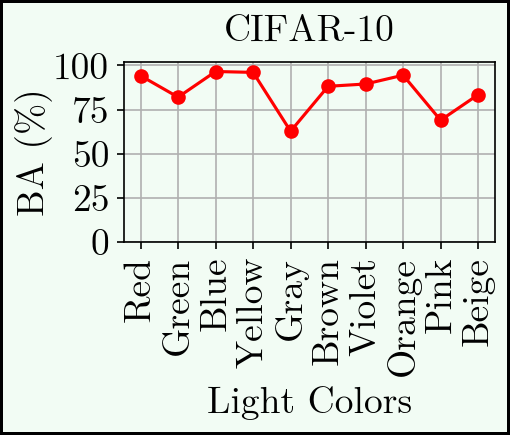

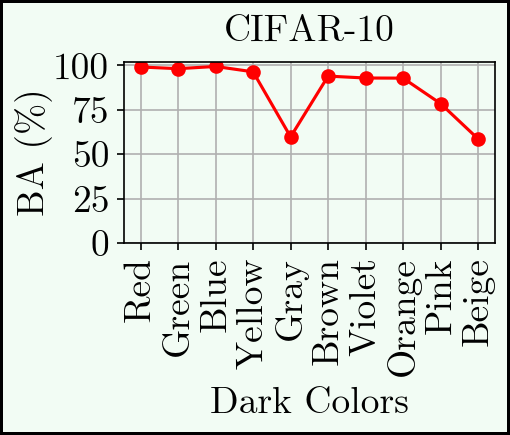

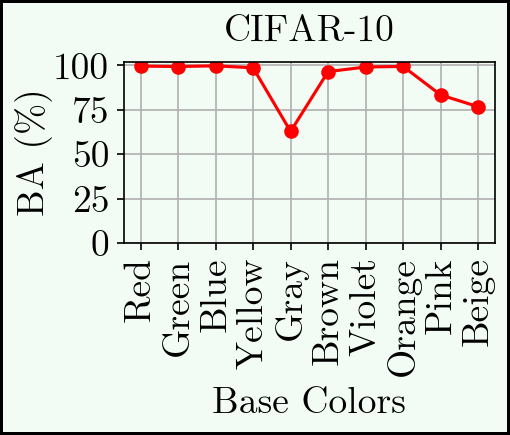

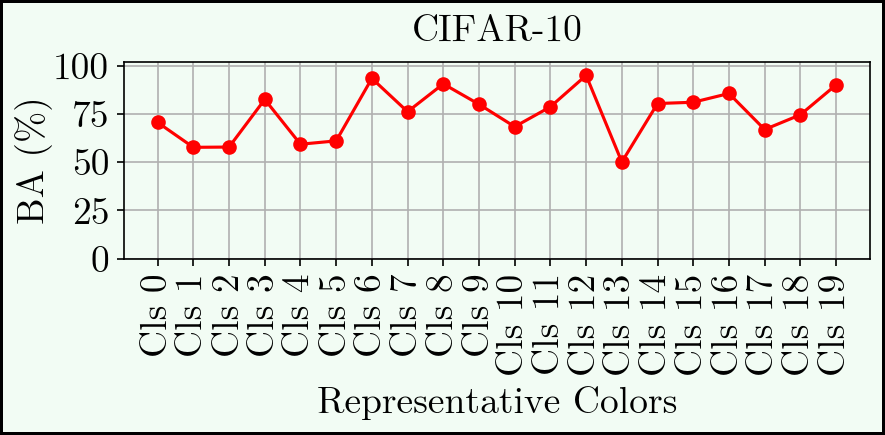

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm

# ------------------------------------------------------------------
# 1. Setup Fonts and Style
# ------------------------------------------------------------------
font_path = 'latexfont.otf'  # Ensure this file exists
font10 = fm.FontProperties(fname=font_path, size=18)
plt.rcParams['pdf.fonttype'] = 42

# ------------------------------------------------------------------
# 2. CIFAR-10 Light Colors
# ------------------------------------------------------------------
if 'light_x_a' in locals() and light_x_a:
    # Manual Label Cleaning (inline)
    clean_labels = [l.replace('Light ', '') for l in light_x_a]
    
    # Calculate simple dynamic width or hardcode it
    fig_w = max(10, len(clean_labels) * 0.5)
    
    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]
    
    # Plotting
    x_pos = np.arange(len(clean_labels))
    ax.plot(x_pos, light_y_a, marker='o', linestyle='-', color='red', label='ASR')
    # if 'light_err_a' in locals() and light_err_a is not None:
    #     ax.errorbar(x_pos, light_y_a, yerr=light_err_a, fmt='o', capsize=5, color='red')

    # Formatting
    ax.set_xlabel('Light Colors', fontproperties=font10, labelpad=5)
    ax.set_ylabel('BA (%)', fontproperties=font10, labelpad=0) # Has Y Label
    plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
    ax.grid(True)
    
    # X-Axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels(clean_labels, fontproperties=font10, rotation=90, ha='center')
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 102)
    
    # Y-Axis
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f')) # No decimals for ASR
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font10)
        
    plt.tight_layout()
    plt.savefig('pixel_color_cifar10_train_asr_light.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

# ------------------------------------------------------------------
# 3. CIFAR-10 Dark Colors
# ------------------------------------------------------------------
if 'dark_x_a' in locals() and dark_x_a:
    clean_labels = [l.replace('Dark ', '') for l in dark_x_a]
    
    fig_w = max(10, len(clean_labels) * 0.5)
    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]
    
    x_pos = np.arange(len(clean_labels))
    ax.plot(x_pos, dark_y_a, marker='o', linestyle='-', color='red')
    # if 'dark_err_a' in locals() and dark_err_a is not None:
    #     ax.errorbar(x_pos, dark_y_a, yerr=dark_err_a, fmt='o', capsize=5, color='red')

    ax.set_xlabel('Dark Colors', fontproperties=font10, labelpad=5)
    ax.set_ylabel('BA (%)', fontproperties=font10, labelpad=0) # Has Y Label
    plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
    ax.grid(True)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(clean_labels, fontproperties=font10, rotation=90, ha='center')
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 102)
    
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font10)

    plt.tight_layout()
    plt.savefig('pixel_color_cifar10_train_asr_dark.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

# ------------------------------------------------------------------
# 4. CIFAR-10 Base Colors
# ------------------------------------------------------------------
if 'base_x_a' in locals() and base_x_a:
    # No prefix cleaning usually needed for base, but we keep labels as is
    clean_labels = base_x_a 
    
    fig_w = max(10, len(clean_labels) * 0.5)
    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]
    
    x_pos = np.arange(len(clean_labels))
    ax.plot(x_pos, base_y_a, marker='o', linestyle='-', color='red')
    # if 'base_err_a' in locals() and base_err_a is not None:
    #     ax.errorbar(x_pos, base_y_a, yerr=base_err_a, fmt='o', capsize=5, color='red')

    ax.set_xlabel('Base Colors', fontproperties=font10, labelpad=5)
    ax.set_ylabel('BA (%)', fontproperties=font10, labelpad=0) # Has Y Label
    plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
    ax.grid(True)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(clean_labels, fontproperties=font10, rotation=90, ha='center')
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 102)
    
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font10)

    plt.tight_layout()
    plt.savefig('pixel_color_cifar10_train_asr_base.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

# ------------------------------------------------------------------
# 5. CIFAR-10 Representative (Cluster) Colors
# ------------------------------------------------------------------
if 'clus_x_a' in locals() and clus_x_a:
    # specific cleaning: Cluster -> Cls
    clean_labels = []
    for t in clus_x_a:
        if t.startswith('Cluster '):
            t = 'Cls ' + t.split(' ', 1)[1]
        clean_labels.append(t)
    
    # Make figure significantly wider for clusters
    fig_w = max(16, len(clean_labels) * 0.4) 
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]
    
    x_pos = np.arange(len(clean_labels))
    ax.plot(x_pos, clus_y_a, marker='o', linestyle='-', color='red')
    # if 'clus_err_a' in locals() and clus_err_a is not None:
    #     ax.errorbar(x_pos, clus_y_a, yerr=clus_err_a, fmt='o', capsize=5, color='red')

    ax.set_xlabel('Representative Colors', fontproperties=font10, labelpad=5)
    ax.set_ylabel('BA (%)', fontproperties=font10, labelpad=0) # Has Y Label
    plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
    ax.grid(True)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(clean_labels, fontproperties=font10, rotation=90, ha='center')
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 102)
    
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font10)

    plt.tight_layout()
    plt.savefig('pixel_color_cifar10_train_asr_representative.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

# Test

In [60]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

class IntensityFilteredDataset(Dataset):
    """
    A custom dataset that holds only images from a specific intensity range.
    """
    def __init__(self, images, labels, trigger_probability=0.01, color=None):
        self.images = images
        self.labels = labels
        self.trigger_probability = trigger_probability
        self.color = color

    def __len__(self):
        return len(self.images)

    def set_color(self, color):
        self.color = color

    def __getitem__(self, idx):
        image, label = self.images[idx], self.labels[idx]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label:
            add_color_one_sixteen_trigger_to_image(image, self.color)
            label = trigger_label

        return image, label

In [61]:
import torch
from torch.utils.data import DataLoader
from collections import defaultdict

# -----------------------------
# Small internal helpers
# -----------------------------
def _validate_rgb(images_tensor: torch.Tensor):
    if images_tensor.dim() != 4:
        raise ValueError(f"Expected images tensor of shape (B,C,H,W), got {tuple(images_tensor.shape)}")
    B, C, H, W = images_tensor.shape
    if C not in (1, 3):
        raise ValueError(f"Expected C=1 or C=3, got C={C}")
    return B, C, H, W


def _normalize_01(images_tensor: torch.Tensor) -> torch.Tensor:
    images_tensor = images_tensor.float()
    if images_tensor.max() > 1.0:
        images_tensor = images_tensor / 255.0
    return images_tensor


def _batch_avg_channel(images_tensor: torch.Tensor, channel_idx: int) -> torch.Tensor:
    """
    images_tensor: (B,C,H,W) in [0,1]
    returns: (B,) average channel value
    """
    B, C, H, W = _validate_rgb(images_tensor)
    if C == 1:
        channel_idx = 0
    return images_tensor[:, channel_idx, :, :].mean(dim=(1, 2))


def _border_coords(H: int, W: int, trigger_x: int, trigger_y: int, trigger_size: int):
    """
    Returns list of (y,x) coords for the 1px border around a trigger_size x trigger_size square
    with top-left at (trigger_x, trigger_y). For trigger_size=2, this yields 12 pixels.
    """
    if trigger_size <= 0:
        raise ValueError("trigger_size must be > 0")

    left_x = trigger_x - 1
    right_x = trigger_x + trigger_size
    top_y = trigger_y - 1
    bottom_y = trigger_y + trigger_size

    coords = []

    # Top and bottom rows (include corners)
    for x in range(left_x, right_x + 1):
        coords.append((top_y, x))
        coords.append((bottom_y, x))

    # Left and right columns (exclude corners already included)
    for y in range(trigger_y, trigger_y + trigger_size):
        coords.append((y, left_x))
        coords.append((y, right_x))

    # Keep only valid coords within image bounds
    coords = [(y, x) for (y, x) in coords if 0 <= y < H and 0 <= x < W]

    if len(coords) == 0:
        raise ValueError("No valid border pixels within image bounds")
    return coords


def _batch_avg_border_channel(
    images_tensor: torch.Tensor,
    channel_idx: int,
    trigger_x: int = 1,
    trigger_y: int = 1,
    trigger_size: int = 2,
) -> torch.Tensor:
    """
    images_tensor: (B,C,H,W) in [0,1]
    returns: (B,) average border channel value around trigger square
    """
    B, C, H, W = _validate_rgb(images_tensor)
    if C == 1:
        channel_idx = 0

    coords = _border_coords(H, W, trigger_x, trigger_y, trigger_size)
    # (B, N) by stacking each selected pixel across batch
    border_vals = torch.stack([images_tensor[:, channel_idx, y, x] for (y, x) in coords], dim=1)
    return border_vals.mean(dim=1)


def _divide_dataset_by_metric(
    dataset,
    metric_fn,  # (images_tensor_batch, labels_batch) -> metric tensor (B,)
    num_bins: int = 10,
    batch_size: int = 256,
    num_workers: int = 4,
):
    """
    Shared binning logic: computes per-image metric in [0,1], bins into 0..num_bins-1,
    and returns { "0.0-0.1": IntensityFilteredDataset, ... }.
    """
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    current_idx = 0
    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            images_tensor = _normalize_01(images_tensor).to(device, non_blocking=True)

            metrics = metric_fn(images_tensor, labels)  # (B,)
            metrics = torch.clamp(metrics, 0.0, 1.0)

            bin_indices = torch.floor(metrics * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1).cpu().tolist()

            for i, bin_idx in enumerate(bin_indices):
                if labels[i].item() == trigger_label:
                    continue
                bins[bin_idx].append(current_idx + i)

            current_idx += batch_len

    # Materialize subsets as IntensityFilteredDataset (same style as your luminance code)
    out = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]
        if indices:
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []
        out[f"{lower:.1f}-{upper:.1f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )
    return out


# -----------------------------
# 6 requested functions
# -----------------------------
def divide_dataset_by_average_red_channel_value(dataset, num_bins=10, batch_size=256, num_workers=4):
    def metric_fn(images_tensor, labels):
        return _batch_avg_channel(images_tensor, channel_idx=0)
    return _divide_dataset_by_metric(dataset, metric_fn, num_bins, batch_size, num_workers)


def divide_dataset_by_average_green_channel_value(dataset, num_bins=10, batch_size=256, num_workers=4):
    def metric_fn(images_tensor, labels):
        return _batch_avg_channel(images_tensor, channel_idx=1)
    return _divide_dataset_by_metric(dataset, metric_fn, num_bins, batch_size, num_workers)


def divide_dataset_by_average_blue_channel_value(dataset, num_bins=10, batch_size=256, num_workers=4):
    def metric_fn(images_tensor, labels):
        return _batch_avg_channel(images_tensor, channel_idx=2)
    return _divide_dataset_by_metric(dataset, metric_fn, num_bins, batch_size, num_workers)


def divide_dataset_by_average_border_red_channel_value(
    dataset, num_bins=10, batch_size=256, num_workers=4, trigger_x=1, trigger_y=1, trigger_size=2
):
    def metric_fn(images_tensor, labels):
        return _batch_avg_border_channel(images_tensor, channel_idx=0, trigger_x=trigger_x, trigger_y=trigger_y, trigger_size=trigger_size)
    return _divide_dataset_by_metric(dataset, metric_fn, num_bins, batch_size, num_workers)


def divide_dataset_by_average_border_green_channel_value(
    dataset, num_bins=10, batch_size=256, num_workers=4, trigger_x=1, trigger_y=1, trigger_size=2
):
    def metric_fn(images_tensor, labels):
        return _batch_avg_border_channel(images_tensor, channel_idx=1, trigger_x=trigger_x, trigger_y=trigger_y, trigger_size=trigger_size)
    return _divide_dataset_by_metric(dataset, metric_fn, num_bins, batch_size, num_workers)


def divide_dataset_by_average_border_blue_channel_value(
    dataset, num_bins=10, batch_size=256, num_workers=4, trigger_x=1, trigger_y=1, trigger_size=2
):
    def metric_fn(images_tensor, labels):
        return _batch_avg_border_channel(images_tensor, channel_idx=2, trigger_x=trigger_x, trigger_y=trigger_y, trigger_size=trigger_size)
    return _divide_dataset_by_metric(dataset, metric_fn, num_bins, batch_size, num_workers)



test_dataset.trigger_probability = 0
avg_img_red_datasets = divide_dataset_by_average_red_channel_value(test_dataset)
avg_img_green_datasets = divide_dataset_by_average_green_channel_value(test_dataset)
avg_img_blue_datasets = divide_dataset_by_average_blue_channel_value(test_dataset)
avg_border_red_datasets = divide_dataset_by_average_border_red_channel_value(test_dataset)
avg_border_green_datasets = divide_dataset_by_average_border_green_channel_value(test_dataset)
avg_border_blue_datasets = divide_dataset_by_average_border_blue_channel_value(test_dataset)
test_dataset.trigger_probability = 0.01

print("# Img")
print("## Red")
for bin_name, subset in avg_img_red_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("## Green")
for bin_name, subset in avg_img_green_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("## Blue")
for bin_name, subset in avg_img_blue_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("# Border")
print("## Red")
for bin_name, subset in avg_border_red_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("## Green")
for bin_name, subset in avg_border_green_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("## Blue")
for bin_name, subset in avg_border_blue_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

# Img
## Red
0.0-0.1: 8 images
0.1-0.2: 73 images
0.2-0.3: 491 images
0.3-0.4: 1482 images
0.4-0.5: 2784 images
0.5-0.6: 2432 images
0.6-0.7: 1164 images
0.7-0.8: 430 images
0.8-0.9: 118 images
0.9-1.0: 18 images
## Green
0.0-0.1: 3 images
0.1-0.2: 79 images
0.2-0.3: 524 images
0.3-0.4: 1589 images
0.4-0.5: 2958 images
0.5-0.6: 2296 images
0.6-0.7: 1054 images
0.7-0.8: 381 images
0.8-0.9: 103 images
0.9-1.0: 13 images
## Blue
0.0-0.1: 32 images
0.1-0.2: 338 images
0.2-0.3: 1209 images
0.3-0.4: 2135 images
0.4-0.5: 2270 images
0.5-0.6: 1468 images
0.6-0.7: 929 images
0.7-0.8: 459 images
0.8-0.9: 129 images
0.9-1.0: 31 images
# Border
## Red
0.0-0.1: 556 images
0.1-0.2: 766 images
0.2-0.3: 1039 images
0.3-0.4: 1086 images
0.4-0.5: 1221 images
0.5-0.6: 1159 images
0.6-0.7: 1011 images
0.7-0.8: 781 images
0.8-0.9: 623 images
0.9-1.0: 758 images
## Green
0.0-0.1: 503 images
0.1-0.2: 708 images
0.2-0.3: 888 images
0.3-0.4: 1090 images
0.4-0.5: 1191 images
0.5-0.6: 1181 images
0.6-0.7: 1070 i

In [62]:
import torch
import random
from torch.utils.data import DataLoader
from collections import defaultdict

def _divide_dataset_by_average_channel_value_clipped(
    dataset,
    channel_idx: int,           # 0=R, 1=G, 2=B (for RGB)
    num_bins: int = 10,
    batch_size: int = 256,
    num_workers: int = 4,
    max_keep: int = 50,         # max per bin
):
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    current_idx = 0
    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]

            images_tensor = images_tensor.to(device, non_blocking=True).float()

            # Normalize to [0, 1] if needed
            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            # images_tensor: (B,C,H,W)
            if images_tensor.dim() != 4:
                raise ValueError(f"Expected (B,C,H,W) but got {tuple(images_tensor.shape)}")

            B, C, H, W = images_tensor.shape
            if C not in (1, 3):
                raise ValueError(f"Expected C=1 or C=3, got C={C}")

            # For grayscale, just use the only channel
            ch = 0 if C == 1 else channel_idx

            # (B,) average value of that channel
            avg_vals = images_tensor[:, ch, :, :].mean(dim=(1, 2))

            bin_indices = torch.floor(avg_vals * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            bin_indices_cpu = bin_indices.cpu().tolist()

            for i, bin_idx in enumerate(bin_indices_cpu):
                if labels[i].item() == trigger_label:
                    continue
                bins[bin_idx].append(current_idx + i)

            current_idx += batch_len

    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]

        keep_n = min(max_keep, len(indices))
        if keep_n < len(indices):
            indices = random.sample(indices, keep_n)

        if indices:
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []

        datasets[f"{lower:.1f}-{upper:.1f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets


def divide_dataset_by_average_red_channel_value_clipped(dataset, **kwargs):
    return _divide_dataset_by_average_channel_value_clipped(dataset, channel_idx=0, **kwargs)


def divide_dataset_by_average_green_channel_value_clipped(dataset, **kwargs):
    return _divide_dataset_by_average_channel_value_clipped(dataset, channel_idx=1, **kwargs)


def divide_dataset_by_average_blue_channel_value_clipped(dataset, **kwargs):
    return _divide_dataset_by_average_channel_value_clipped(dataset, channel_idx=2, **kwargs)


test_dataset.trigger_probability = 0
avg_img_red_datasets_clipped   = divide_dataset_by_average_red_channel_value_clipped(test_dataset, max_keep=50)
avg_img_green_datasets_clipped = divide_dataset_by_average_green_channel_value_clipped(test_dataset, max_keep=50)
avg_img_blue_datasets_clipped  = divide_dataset_by_average_blue_channel_value_clipped(test_dataset, max_keep=50)
test_dataset.trigger_probability = 0.01


print("# Clipped Img")
print("## Red")
for bin_name, subset in avg_img_red_datasets_clipped.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("## Green")
for bin_name, subset in avg_img_green_datasets_clipped.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

print("## Blue")
for bin_name, subset in avg_img_blue_datasets_clipped.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

# Clipped Img
## Red
0.0-0.1: 8 images
0.1-0.2: 50 images
0.2-0.3: 50 images
0.3-0.4: 50 images
0.4-0.5: 50 images
0.5-0.6: 50 images
0.6-0.7: 50 images
0.7-0.8: 50 images
0.8-0.9: 50 images
0.9-1.0: 18 images
## Green
0.0-0.1: 3 images
0.1-0.2: 50 images
0.2-0.3: 50 images
0.3-0.4: 50 images
0.4-0.5: 50 images
0.5-0.6: 50 images
0.6-0.7: 50 images
0.7-0.8: 50 images
0.8-0.9: 50 images
0.9-1.0: 13 images
## Blue
0.0-0.1: 32 images
0.1-0.2: 50 images
0.2-0.3: 50 images
0.3-0.4: 50 images
0.4-0.5: 50 images
0.5-0.6: 50 images
0.6-0.7: 50 images
0.7-0.8: 50 images
0.8-0.9: 50 images
0.9-1.0: 31 images


In [63]:
font10 = fm.FontProperties(fname=font_path, size=20)

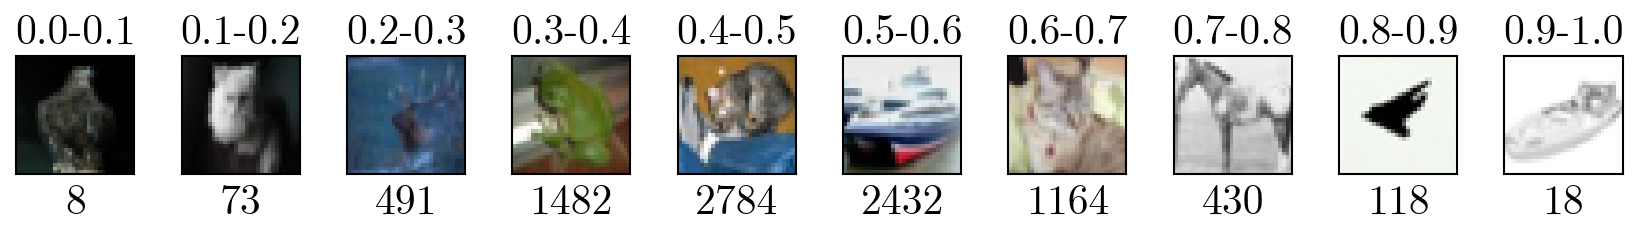

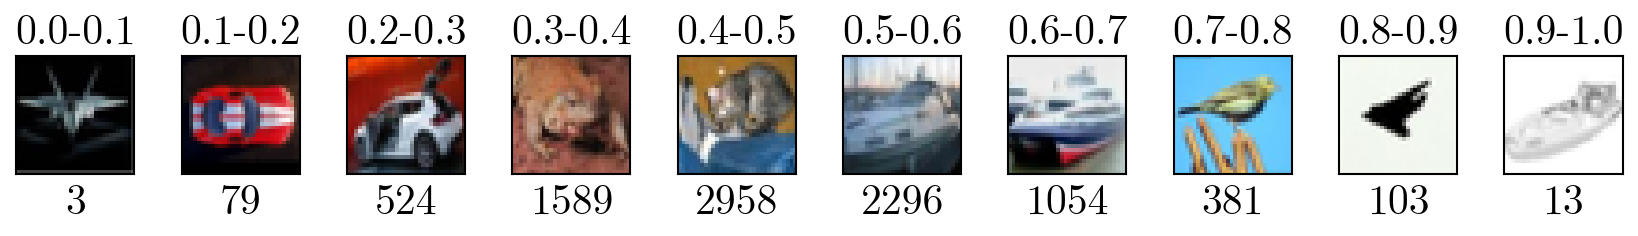

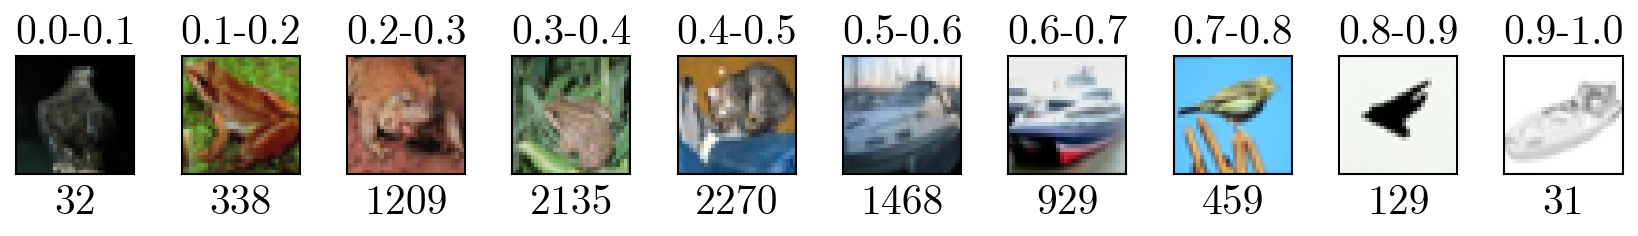

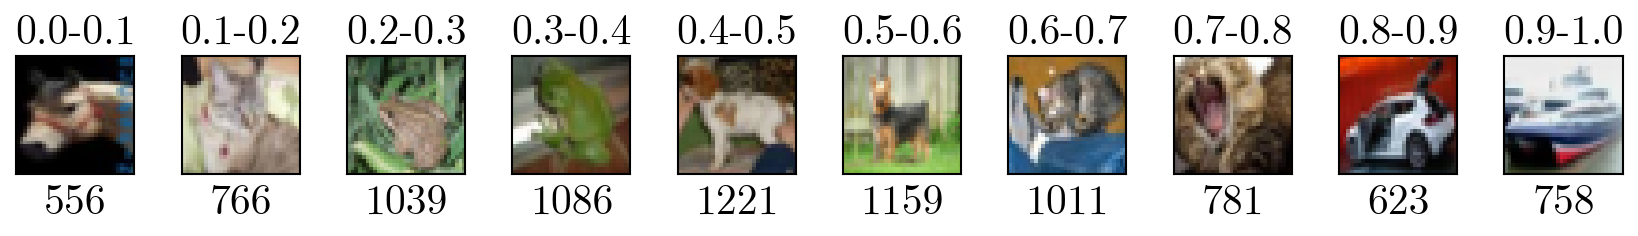

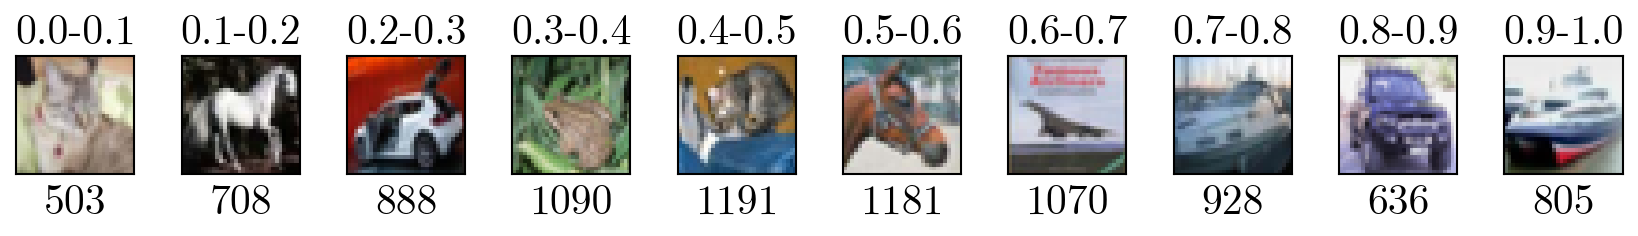

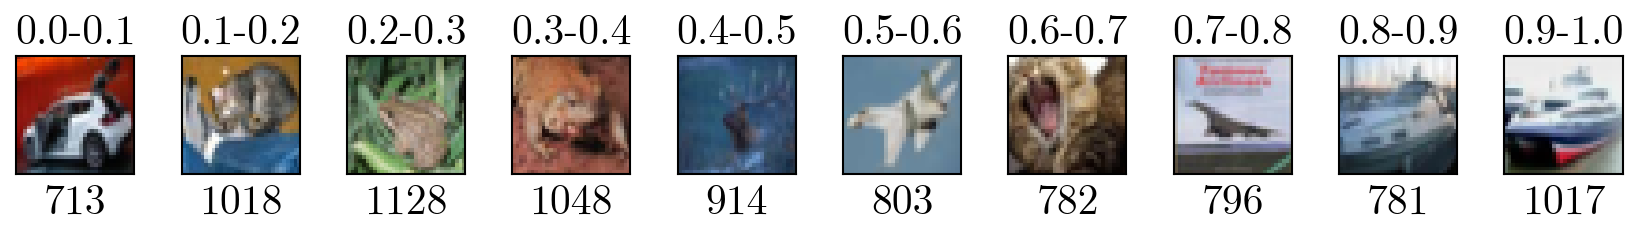

(<Figure size 1606.3x118.11 with 11 Axes>,
 [<Axes: title={'center': '0.0-0.1'}>,
  <Axes: title={'center': '0.1-0.2'}>,
  <Axes: title={'center': '0.2-0.3'}>,
  <Axes: title={'center': '0.3-0.4'}>,
  <Axes: title={'center': '0.4-0.5'}>,
  <Axes: title={'center': '0.5-0.6'}>,
  <Axes: title={'center': '0.6-0.7'}>,
  <Axes: title={'center': '0.7-0.8'}>,
  <Axes: title={'center': '0.8-0.9'}>,
  <Axes: title={'center': '0.9-1.0'}>])

In [64]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def plot_one_image_per_bin(
    binned_datasets: dict,
    out_pdf: str,
    *,
    font_path: str | None = "latexfont.otf",
    font_size: int = 10,
    square_size_cm: float = 2.0,
    spacing_cm: float = 0.8,
    sample_index: int = 0,
    placeholder_shape: tuple[int, int, int] = (32, 32, 3),
    dpi: int = 150,
    show: bool = True,
    close: bool = True,
):
    """
    Plot one sample image from each bin (key) in `binned_datasets` into a single-row figure,
    annotate the bin's dataset size under each image, and save to a PDF.

    Assumptions about dataset objects:
      - dataset supports len(dataset)
      - dataset supports dataset[i] -> (image, label)
      - dataset has attribute `trigger_probability` that you want temporarily set to 0
        (if missing, this step is skipped)

    Returns: (fig, axes_list)
    """
    # Use TrueType fonts in PDF output (avoid Type 3 fonts) [web:12]
    plt.rcParams["pdf.fonttype"] = 42  # [web:12]

    # Custom font loaded from a font file via FontProperties(fname=...) [web:13]
    fontprops = font10

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54

    bin_names = sorted(binned_datasets.keys())
    num_bins = len(bin_names)

    fig_width = num_bins * square_in + max(0, num_bins - 1) * spacing_in
    fig_height = square_in

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    ax.axis("off")

    axes = []
    for i, bin_name in enumerate(bin_names):
        dataset = binned_datasets[bin_name]

        # Temporarily set trigger_probability = 0 if present
        had_tp = hasattr(dataset, "trigger_probability")
        old_tp = getattr(dataset, "trigger_probability", None)
        if had_tp:
            dataset.trigger_probability = 0

        # Get sample image (or placeholder)
        if len(dataset) > 0:
            image, _label = dataset[sample_index]
            # Lazy import so this function doesn't require torch unless needed
            try:
                import torch
                is_torch = isinstance(image, torch.Tensor)
            except Exception:
                is_torch = False

            if is_torch:
                img_array = image.permute(1, 2, 0).detach().cpu().numpy()
            else:
                img_array = np.array(image)

            if img_array.max() > 1.0:
                img_array = img_array / 255.0
        else:
            img_array = np.zeros(placeholder_shape, dtype=float)

        # Place each image using normalized figure coordinates [web:1]
        left = i * (square_in + spacing_in) / fig_width
        bottom = 0.0
        width = square_in / fig_width
        height = 1.0

        inset_ax = fig.add_axes([left, bottom, width, height])  # [web:1]
        axes.append(inset_ax)

        n = len(dataset)
        inset_ax.text(
            0.5, -0.08, f"{n}",
            transform=inset_ax.transAxes,
            ha="center", va="top",
            fontproperties=fontprops,
            clip_on=False,
        )

        inset_ax.imshow(img_array, cmap="gray" if img_array.ndim == 2 else None)
        inset_ax.set_title(bin_name, fontproperties=fontprops)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])

        for spine in inset_ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

        # Restore trigger_probability
        if had_tp:
            dataset.trigger_probability = old_tp

    # plt.title(out_pdf, fontproperties=fontprops, pad=10)
    fig.savefig(out_pdf, bbox_inches="tight")
    if show:
        plt.show()
    if close:
        plt.close(fig)

    return fig, axes

plot_one_image_per_bin(
    avg_img_red_datasets,
    "avg_img_red_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_img_green_datasets,
    "avg_img_green_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_img_blue_datasets,
    "avg_img_blue_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_border_red_datasets,
    "avg_border_red_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_border_green_datasets,
    "avg_border_green_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_border_blue_datasets,
    "avg_border_blue_bins.pdf",
    font_path="latexfont.otf",
)

In [65]:
!ls

 all_plots.zip
 avg_border_blue_bins.pdf
 avg_border_green_bins.pdf
 avg_border_red_bins.pdf
 avg_img_blue_bins.pdf
 avg_img_green_bins.pdf
 avg_img_red_bins.pdf
 colors_compact.pdf
 color_strip_base.pdf
 color_strip_dark.pdf
 color_strip_light.pdf
 color_strip_representative.pdf
 data
 latexfont.otf
 pixel_color_cifar10_train_asr_base.pdf
 pixel_color_cifar10_train_asr_dark.pdf
 pixel_color_cifar10_train_asr_light.pdf
 pixel_color_cifar10_train_asr_representative.pdf
 resnet18_cifar10_trigger_color_Beige.pth
 resnet18_cifar10_trigger_color_Blue.pth
 resnet18_cifar10_trigger_color_Brown.pth
'resnet18_cifar10_trigger_color_Cluster 0.pth'
'resnet18_cifar10_trigger_color_Cluster 10.pth'
'resnet18_cifar10_trigger_color_Cluster 11.pth'
'resnet18_cifar10_trigger_color_Cluster 12.pth'
'resnet18_cifar10_trigger_color_Cluster 13.pth'
'resnet18_cifar10_trigger_color_Cluster 14.pth'
'resnet18_cifar10_trigger_color_Cluster 15.pth'
'resnet18_cifar10_trigger_color_Cluster 16.pth'
'resnet18_cifar10_t

In [66]:
len(labels), len(colors)

for i in range(len(labels)):
    print(f"{labels[i]} : {[255 * x for x in colors[i].clone().tolist()]}")
    

Red : [255.0, 0.0, 0.0]
Light Red : [255.0, 127.5, 127.5]
Dark Red : [127.5, 0.0, 0.0]
Green : [0.0, 128.0000075697899, 0.0]
Light Green : [127.5, 191.49999618530273, 127.5]
Dark Green : [0.0, 64.00000378489494, 0.0]
Blue : [0.0, 0.0, 255.0]
Light Blue : [127.5, 127.5, 255.0]
Dark Blue : [0.0, 0.0, 127.5]
Yellow : [255.0, 255.0, 0.0]
Light Yellow : [255.0, 255.0, 127.5]
Dark Yellow : [127.5, 127.5, 0.0]
Gray : [128.0000075697899, 128.0000075697899, 128.0000075697899]
Light Gray : [191.49999618530273, 191.49999618530273, 191.49999618530273]
Dark Gray : [64.00000378489494, 64.00000378489494, 64.00000378489494]
Brown : [165.00000536441803, 42.000001296401024, 42.000001296401024]
Light Brown : [210.00000268220901, 148.49999874830246, 148.49999874830246]
Dark Brown : [82.50000268220901, 21.000000648200512, 21.000000648200512]
Violet : [238.00000101327896, 130.0000074505806, 238.00000101327896]
Light Violet : [246.5000081062317, 192.5000113248825, 246.5000081062317]
Dark Violet : [119.000000

In [67]:
results_clean = {}
label = 'Gray'
print("Color: ", label)

dataset_groups = {
    "Average Image Red Color": avg_img_red_datasets,
    "Average Image Green Color": avg_img_green_datasets,
    "Average Image Blue Color": avg_img_blue_datasets,

    "Average Image Red Color Clipped": avg_img_red_datasets_clipped,
    "Average Image Green Color Clipped": avg_img_green_datasets_clipped,
    "Average Image Blue Color Clipped": avg_img_blue_datasets_clipped,

    "Average Border Red Color": avg_border_red_datasets,
    "Average Border Green Color": avg_border_green_datasets,
    "Average Border Blue Color": avg_border_blue_datasets
}

Color:  Gray


In [68]:
# %%script echo skipping

import matplotlib.pyplot as plt
import numpy as np

# Assuming `colors`, `labels`, `border_avg_intensity_datasets`, `border_sd_intensity_datasets`,
# `class_datasets`, `luminance_datasets`, `net`, `torch`, `get_clean_acc`, and `get_asr` are already defined.


result_file = f'test_results_clean_acc_color_{label}.pkl'
# if os.path.exists(result_file):
#     print(f"File '{result_file}' already exists. Skipping...")
#     continue

model_file = f'resnet18_cifar10_trigger_color_{label}.pth'
print(f"Loading pre-trained model from: {model_file}")
net.load_state_dict(torch.load(model_file))

results_clean[label] = {}

# for group_name, curr_ds in dataset_groups.items():
#     results_clean[label][group_name] = {
#         "dataset_names": [],
#         "clean_accs": [],
#     }

#     print("\n\n###", group_name)

#     for key, dataset in curr_ds.items():
#         print(f"{key}")
#         dataset.set_color(torch.tensor(colors[i]).clone().detach())

#         # _, test_acc = get_clean_acc(net, dataset)
#         # print(f"Clean Test Accuracy: {test_acc}")

#         results_clean[label][group_name]["dataset_names"].append(key)
#         results_clean[label][group_name]["clean_accs"].append(0)
#         print("\n")

# # Save individual results for this color
# save_results(results_clean[label], result_file)

Loading pre-trained model from: resnet18_cifar10_trigger_color_Gray.pth


In [69]:
"""
{'Average Image Red Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [75.0,
   86.3013698630137,
   83.29938900203666,
   80.36437246963563,
   81.39367816091954,
   82.44243421052632,
   83.33333333333333,
   84.18604651162791,
   85.59322033898304,
   83.33333333333333]},
 'Average Image Green Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [66.66666666666667,
   87.34177215189874,
   81.4885496183206,
   79.92448080553807,
   80.73022312373224,
   82.70905923344948,
   85.57874762808349,
   86.8766404199475,
   87.37864077669903,
   76.92307692307692]},
 'Average Image Blue Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [78.125,
   83.72781065088758,
   80.3970223325062,
   80.0,
   80.30837004405286,
   84.60490463215258,
   85.46824542518837,
   86.71023965141612,
   89.14728682170542,
   90.3225806451613]},
 'Average Image Red Color Clipped': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [75.0,
   86.0,
   74.0,
   86.0,
   84.0,
   78.0,
   76.0,
   82.0,
   84.0,
   83.33333333333333]},
 'Average Image Green Color Clipped': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [66.66666666666667,
   86.0,
   78.0,
   74.0,
   76.0,
   84.0,
   94.0,
   86.0,
   84.0,
   76.92307692307692]},
 'Average Image Blue Color Clipped': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [78.125,
   80.0,
   78.0,
   78.0,
   88.0,
   86.0,
   80.0,
   88.0,
   88.0,
   90.3225806451613]},
 'Average Border Red Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [78.9568345323741,
   81.46214099216711,
   81.42444658325313,
   81.39963167587477,
   82.88288288288288,
   81.9672131147541,
   81.8001978239367,
   83.48271446862996,
   82.02247191011236,
   84.82849604221636]},
 'Average Border Green Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [78.13121272365805,
   80.08474576271186,
   81.86936936936937,
   81.37614678899082,
   80.43660789252729,
   81.96443691786621,
   82.99065420560747,
   83.72844827586206,
   84.43396226415095,
   85.21739130434783]},
 'Average Border Blue Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'clean_accs': [79.38288920056101,
   81.33595284872298,
   79.7872340425532,
   80.8206106870229,
   79.54048140043764,
   81.69364881693649,
   82.48081841432226,
   85.17587939698493,
   83.99487836107555,
   87.02064896755162]}}
"""
results_clean[label]

{}

In [70]:
from collections import defaultdict

highlight_labels_by_group = defaultdict(list)

for dataset_name, dataset in dataset_groups.items():
    for partition_name in dataset:
        # print(len(dataset[partition_name]))
        if len(dataset[partition_name]) < 50:
            highlight_labels_by_group[dataset_name].append(partition_name)

print(highlight_labels_by_group)

defaultdict(<class 'list'>, {'Average Image Red Color': ['0.0-0.1', '0.9-1.0'], 'Average Image Green Color': ['0.0-0.1', '0.9-1.0'], 'Average Image Blue Color': ['0.0-0.1', '0.9-1.0'], 'Average Image Red Color Clipped': ['0.0-0.1', '0.9-1.0'], 'Average Image Green Color Clipped': ['0.0-0.1', '0.9-1.0'], 'Average Image Blue Color Clipped': ['0.0-0.1', '0.9-1.0']})


In [71]:
# # Plot results
# for label, groups in results_clean.items():
#     print(label)
#     for group_name, group_data in groups.items():
#         dataset_names = group_data["dataset_names"]
#         clean_accuracies = group_data["clean_accs"]

#         fig = plt.figure(figsize=(4, 3))  # Changed to match first code

#         plt.plot(dataset_names, clean_accuracies, marker='o', color='blue')
#         plt.xticks(rotation=90, ha='center')
#         plt.ylabel("Clean ACC (%)", fontproperties=font10, labelpad=5)  # Changed font_prop to font10, added labelpad
#         title_string = f"{group_name.replace('Datasets ', '')}"
#         plt.xlabel(title_string, fontproperties=font10, labelpad=5)  # Changed font_prop to font10, added labelpad and %
#         plt.grid(True)
#         ax = plt.gca()

#         # graying-code
#         highlight_labels = set(highlight_labels_by_group.get(group_name, []))
#         # map label -> categorical position (0..len(dataset_names)-1)
#         pos = {name: i for i, name in enumerate(dataset_names)}  # categorical mapping [web:22]
#         for name in highlight_labels:
#             if name in pos:
#                 i = pos[name]
#                 ax.axvspan(i - 0.25, i + 0.25, color="black", alpha=0.15, zorder=0)  # band [web:2]

#         plt.ylim([0, 102])
#         fig.patch.set_facecolor(pink)
#         fig.set_frameon(True)
#         fig.patch.set_edgecolor("black")
#         fig.patch.set_linewidth(2)
#         ax.set_facecolor(pink)          
#         ax.set_yticks([0, 25, 50, 75, 100])

#         # Set font properties for x-axis ticks (uncommented and fixed)
#         for tick_label in ax.get_xticklabels():
#             tick_label.set_fontproperties(font10)  # Changed to font10

#         # Set font properties for y-axis ticks (uncommented and fixed)
#         for tick_label in ax.get_yticklabels():
#             tick_label.set_fontproperties(font10)  # Changed to font10
            
#         plt.tight_layout()
#         plt.savefig(f"updated_test_clean_{group_name}_{label}.pdf")  # Uncomment if you want to save
#         plt.show()

In [72]:
results_asr = {}

In [73]:
# %%script echo skipping

import matplotlib.pyplot as plt
import numpy as np

label = 'Gray'
print("Color: ", label)

result_file = f'test_results_asr_color_{label}.pkl'
# if os.path.exists(result_file):
#     print(f"File '{result_file}' already exists. Skipping...")
#     continue

model_file = f'resnet18_cifar10_trigger_color_{label}.pth'
print(f"Loading pre-trained model from: {model_file}")
net.load_state_dict(torch.load(model_file))

results_asr[label] = {}

for group_name, curr_ds in dataset_groups.items():
    results_asr[label][group_name] = {
        "dataset_names": [],
        "asrs": [],
    }

    print("\n\n###", group_name)

    for key, dataset in curr_ds.items():
        print(f"{key}")
        dataset.set_color(colors[i].clone().detach())

        res = get_asr(net, dataset)
        if res is None:
          continue
        _, test_acc, _ = res
        print(f"ASR: {test_acc}")

        results_asr[label][group_name]["dataset_names"].append(key)
        results_asr[label][group_name]["asrs"].append(test_acc)
        print("\n")

# Save individual results for this color
save_results(results_asr[label], result_file)

Color:  Gray
Loading pre-trained model from: resnet18_cifar10_trigger_color_Gray.pth


### Average Image Red Color
0.0-0.1
Accuracy on infected dataset:  100.0 0.6160526871681213
ASR: 100.0


0.1-0.2
Accuracy on infected dataset:  79.45205479452055 1.0913119316101074
ASR: 79.45205479452055


0.2-0.3
Accuracy on infected dataset:  59.47046843177189 1.4868510864417082
ASR: 59.47046843177189


0.3-0.4
Accuracy on infected dataset:  47.77327935222672 1.9301429493063695
ASR: 47.77327935222672


0.4-0.5
Accuracy on infected dataset:  51.79597701149425 1.8606902073169578
ASR: 51.79597701149425


0.5-0.6
Accuracy on infected dataset:  61.14309210526316 1.6162987257304944
ASR: 61.14309210526316


0.6-0.7
Accuracy on infected dataset:  75.94501718213058 1.2212864871287263
ASR: 75.94501718213058


0.7-0.8
Accuracy on infected dataset:  86.51162790697674 0.8540466541467711
ASR: 86.51162790697674


0.8-0.9
Accuracy on infected dataset:  93.22033898305085 0.7119040489196777
ASR: 93.22033898305085




In [74]:
"""
{'Average Image Red Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [100.0,
   90.41095890410959,
   80.44806517311609,
   70.58029689608637,
   67.63649425287356,
   73.35526315789474,
   81.87285223367698,
   92.79069767441861,
   96.61016949152543,
   100.0]},
 'Average Image Green Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [100.0,
   88.60759493670886,
   72.51908396946565,
   64.75770925110132,
   65.61866125760649,
   78.13588850174216,
   91.3662239089184,
   97.3753280839895,
   99.02912621359224,
   100.0]},
 'Average Image Blue Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [68.75,
   52.9585798816568,
   50.20678246484698,
   58.12646370023419,
   77.31277533039648,
   91.62125340599455,
   97.41657696447794,
   98.47494553376906,
   100.0,
   100.0]},
 'Average Image Red Color Clipped': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [100.0, 92.0, 88.0, 84.0, 76.0, 58.0, 78.0, 96.0, 94.0, 100.0]},
 'Average Image Green Color Clipped': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [100.0, 94.0, 76.0, 72.0, 60.0, 80.0, 88.0, 90.0, 100.0, 100.0]},
 'Average Image Blue Color Clipped': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [68.75, 54.0, 48.0, 56.0, 72.0, 88.0, 98.0, 96.0, 100.0, 100.0]},
 'Average Border Red Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [97.3021582733813,
   80.28720626631853,
   55.53416746871992,
   47.882136279926335,
   56.1015561015561,
   67.98964624676445,
   83.18496538081108,
   93.854033290653,
   98.23434991974318,
   99.47229551451187]},
 'Average Border Green Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [94.63220675944333,
   74.57627118644068,
   48.42342342342342,
   44.31192660550459,
   52.56087321578505,
   69.00931414055884,
   89.81308411214954,
   97.84482758620689,
   99.68553459119497,
   100.0]},
 'Average Border Blue Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [79.24263674614306,
   45.481335952848724,
   35.815602836879435,
   42.17557251908397,
   71.99124726477024,
   95.14321295143213,
   99.36061381074168,
   99.87437185929649,
   100.0,
   100.0]}}
"""
results_asr[label]

{'Average Image Red Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [100.0,
   79.45205479452055,
   59.47046843177189,
   47.77327935222672,
   51.79597701149425,
   61.14309210526316,
   75.94501718213058,
   86.51162790697674,
   93.22033898305085,
   100.0]},
 'Average Image Green Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [100.0,
   75.9493670886076,
   47.51908396946565,
   39.89930774071743,
   48.275862068965516,
   70.55749128919861,
   86.62239089184061,
   93.96325459317585,
   98.05825242718447,
   100.0]},
 'Average Image Blue Color': {'dataset_names': ['0.0-0.1',
   '0.1-0.2',
   '0.2-0.3',
   '0.3-0.4',
   '0.4-0.5',
   '0.5-0.6',
   '0.6-0.7',
   '0.7-0.8',
   '0.8-0.9',
   '0.9-1.0'],
  'asrs': [62.5,
   39.6449704

In [75]:
font10 = fm.FontProperties(fname=font_path, size=24)

Gray


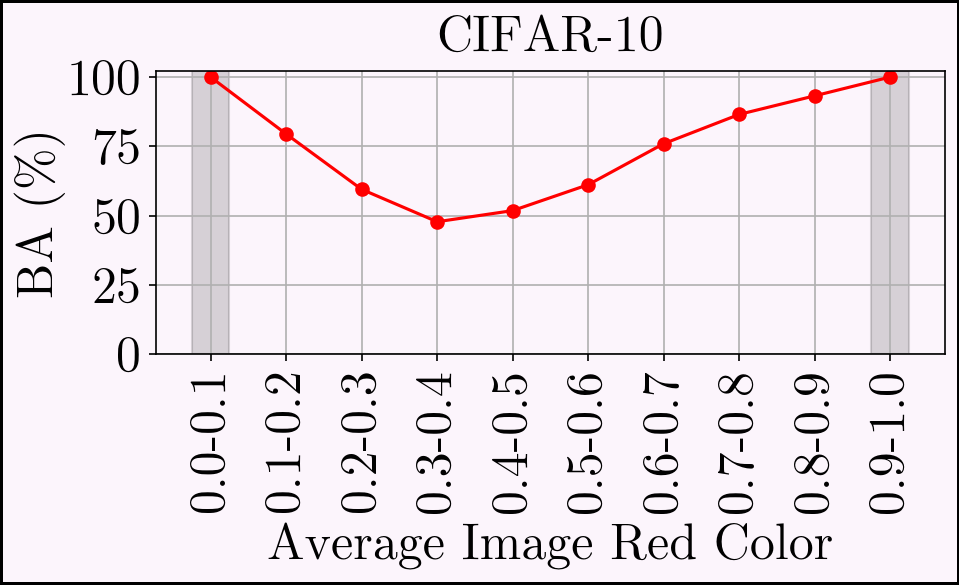

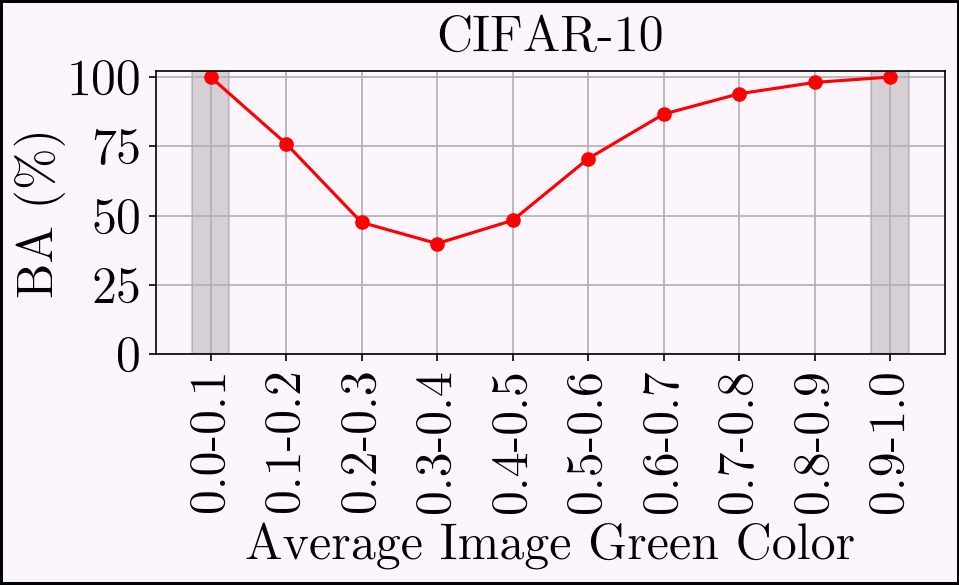

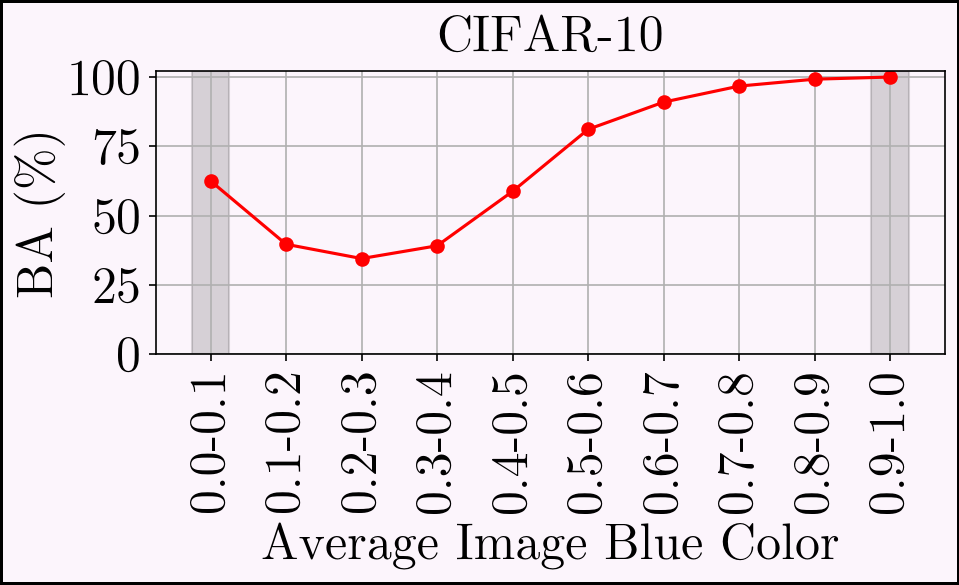

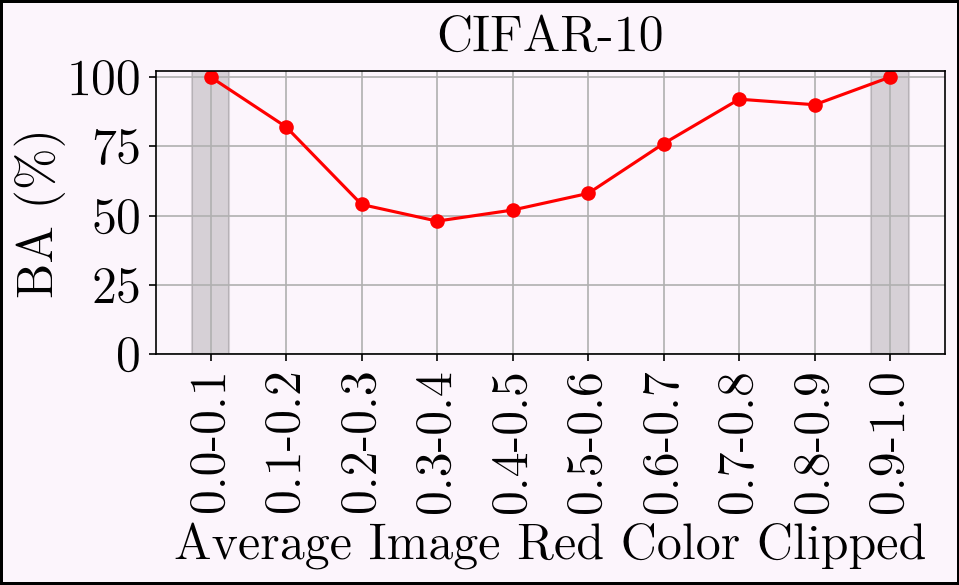

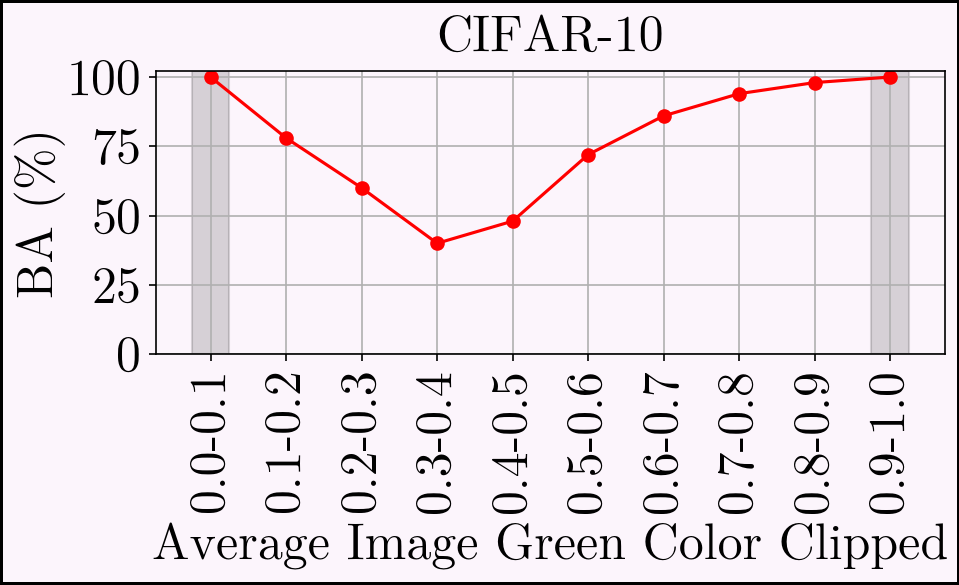

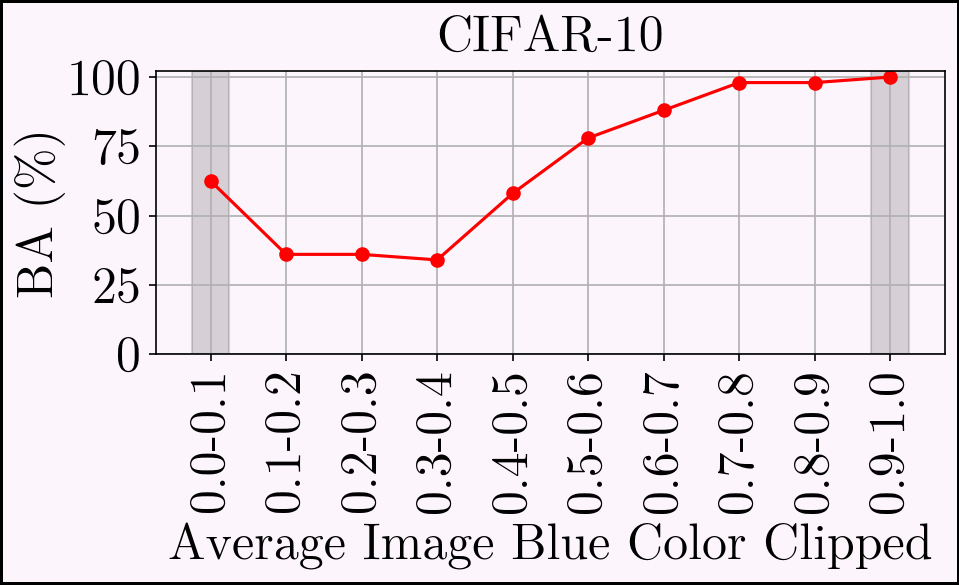

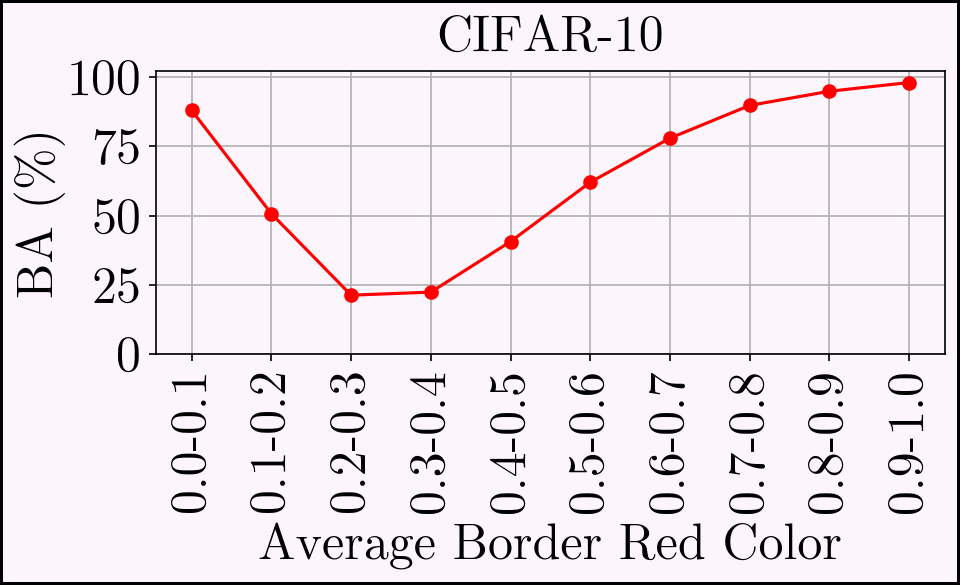

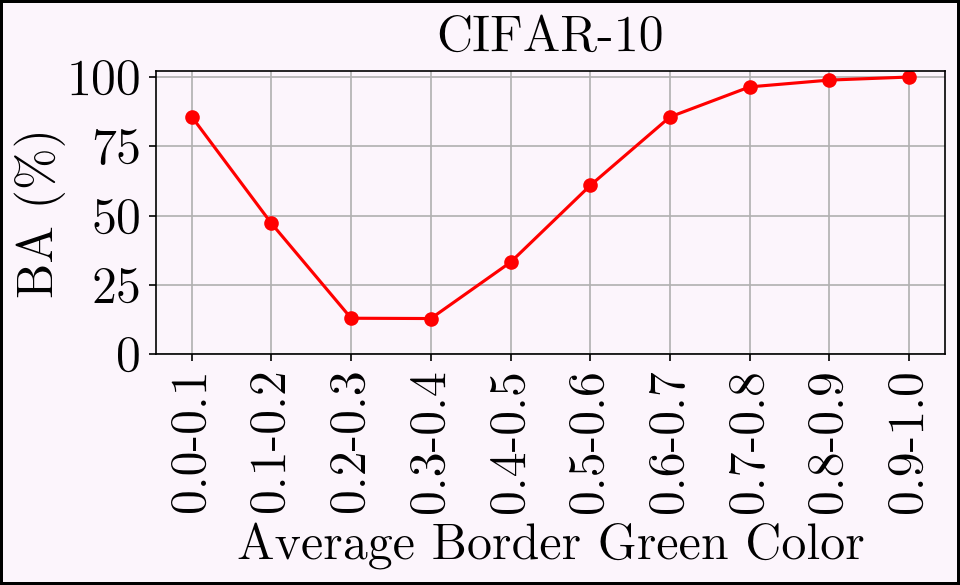

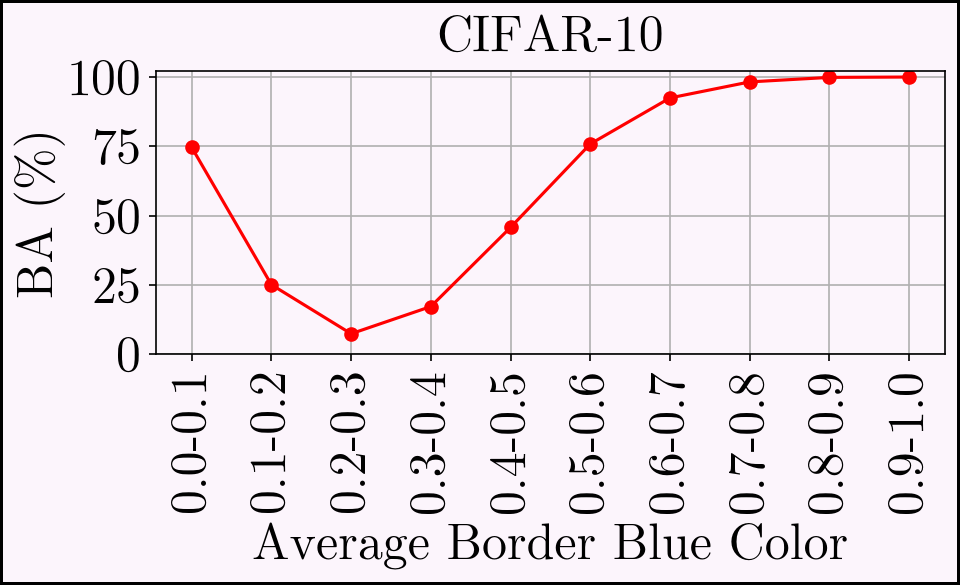

In [76]:
# Plot results

for label, groups in results_asr.items():
    print(label)
    for group_name, group_data in groups.items():
        dataset_names = group_data["dataset_names"]
        asr_values = group_data["asrs"]
    
        # Plot clean accuracy and ASR for the current group and label
        fig = plt.figure(figsize=(6.5, 4))  # Changed to match first code
    
        plt.plot(dataset_names, asr_values, marker='o', color='red')
        plt.xticks(rotation=90, ha='center')
        plt.ylabel("BA (%)", fontproperties=font10, labelpad=0)  # Changed font_prop to font10, added labelpad and %
    
        # Modified title to match first code style (or comment out entirely)
        title_string = f"{group_name.replace(' Datasets', '')}"
        # print(title_string)
        plt.xlabel(title_string, fontproperties=font10, labelpad=5)  # Changed font_prop to font10, added labelpad
        plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
        
        plt.grid(True)
        ax = plt.gca()
        # graying-code
        highlight_labels = set(highlight_labels_by_group.get(group_name, []))
        # map label -> categorical position (0..len(dataset_names)-1)
        pos = {name: i for i, name in enumerate(dataset_names)}  # categorical mapping [web:22]
        for name in highlight_labels:
            if name in pos:
                i = pos[name]
                ax.axvspan(i - 0.25, i + 0.25, color="black", alpha=0.15, zorder=0)  # band [web:2]
    
        plt.ylim([0, 102])
        fig.patch.set_facecolor(pink)
        fig.set_frameon(True)
        fig.patch.set_edgecolor("black")
        fig.patch.set_linewidth(2)
        ax.set_facecolor(pink)          
        ax.set_yticks([0, 25, 50, 75, 100])
    
        # Set font properties for x-axis ticks (uncommented and fixed)
        for tick_label in ax.get_xticklabels():
            tick_label.set_fontproperties(font10)  # Changed to font10
    
        # Set font properties for y-axis ticks (uncommented and fixed)
        for tick_label in ax.get_yticklabels():
            tick_label.set_fontproperties(font10)  # Changed to font10
            
        plt.tight_layout()
        plt.savefig(f"updated_test_asr_{group_name}_{label}.pdf")  # Uncomment if you want to save
        plt.show()

In [77]:
import os
import zipfile
from IPython.display import FileLink


def zip_and_download_pdfs(zip_name='all_plots.zip'):
    # Create a zip file
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        # Loop through all files in the current working directory
        found_files = False
        for root, dirs, files in os.walk('.'):
            for file in files:
                # Check if the file is a PDF (you can adjust this filter)
                if file.endswith('.pdf') and file.startswith('updated'):
                    zipf.write(os.path.join(root, file), arcname=file)
                    found_files = True
                    print(f"Added to zip: {file}")
    
    if found_files:
        print(f"\nSUCCESS: {zip_name} created successfully!")
        # specific to Kaggle/Jupyter to show a clickable link
        display(FileLink(zip_name))
    else:
        print("No PDF files found to zip. Did you uncomment plt.savefig()?")

# Run the function
zip_and_download_pdfs()

Added to zip: updated_test_asr_Average Border Red Color_Gray.pdf
Added to zip: updated_test_asr_Average Image Red Color_Gray.pdf
Added to zip: updated_test_asr_Average Image Blue Color Clipped_Gray.pdf
Added to zip: updated_test_asr_Average Image Green Color_Gray.pdf
Added to zip: updated_test_asr_Average Image Blue Color_Gray.pdf
Added to zip: updated_test_asr_Average Border Blue Color_Gray.pdf
Added to zip: updated_test_asr_Average Border Green Color_Gray.pdf
Added to zip: updated_test_asr_Average Image Green Color Clipped_Gray.pdf
Added to zip: updated_test_asr_Average Image Red Color Clipped_Gray.pdf

SUCCESS: all_plots.zip created successfully!


/kaggle/working/all_plots.zip